v2: clean v1 and comparison with deblender

Test are done with sample up to 24.5 magnitude

In [50]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

## Load transformations of ellipticities

In [2]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

# Load models

## Loading directories

In [3]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'
dir_model_v3 = root_dir_models+'v_no_psf_noisy_256_no_weights/loss/'# Deterministic network
dir_model_v5 = root_dir_models+'v_no_psf_noisy_256_bnn_no_weights/bis/loss/'# BNN

## Set models parameters

In [4]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

## Define and load models

In [5]:
model_det = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_bnn = model.create_model_prob_flipout_peak_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0621 13:41:01.767896 140168951428928 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0621 13:41:02.285111 140168951428928 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.
W0621 13:41:03.105786 140168951428928 deprecation.py:323] From ../../scripts/tools_for_VAE/tool

[4096, 256]
Tensor("dense_flipout/Size:0", shape=(), dtype=int32)
[256, 5]
Tensor("dense_flipout_1/Size:0", shape=(), dtype=int32)


In [6]:
latest = tf.train.latest_checkpoint(dir_model_v3)
model_det.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v5)
model_bnn.load_weights(latest)

# Load data 

In [9]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band

images = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

#data.replace([np.inf, -np.inf], np.nan, inplace=True)
#data = data.dropna(axis = 0, how = 'any')

new_data=data[(np.abs(data['e1_hsm_regauss'])<=1.) &
         (np.abs(data['e2_hsm_regauss'])<=1.) &
             (data['blendedness']>0)]

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])


ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, -shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, -shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, -shear_1, shear_2, convergence))

data['e1_lensed'] = e1
data['e2_lensed'] = e2

In [8]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7878 entries, 2 to 9998
Data columns (total 14 columns):
id                7878 non-null int64
e1                7878 non-null float64
e2                7878 non-null float64
shear_1           7878 non-null float64
shear_2           7878 non-null float64
redshift          7878 non-null float64
redshift_true     7878 non-null float64
blendedness       7878 non-null float64
snr_r             7878 non-null float64
convergence       7878 non-null float64
e1_hsm_regauss    7878 non-null float64
e2_hsm_regauss    7878 non-null float64
mag_r_meas        7878 non-null float64
mag_r_true        7878 non-null float64
dtypes: float64(13), int64(1)
memory usage: 923.2 KB


# Test of models

## Deterministic model

### Perform test

In [10]:
output_v1 = model_det([tf.cast(images[9000:10000], tf.float32), tf.cast(psf[9000:10000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

In [11]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std

df.to_csv('data/df_param_ell_4.csv')

In [107]:
part_1 = pd.read_csv('data/df_param_ell_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_4.csv', encoding = 'utf-8')

df_plot = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

### Plots

In [108]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = df_plot['e1_out_mean']
d['e2'] = df_plot['e2_out_mean']
d['e1_std'] = df_plot['e1_out_std']
d['e2_std'] = df_plot['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss']], ignore_index = True)#, ignore_index=True, sort = True)
df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000

In [109]:
df_plot_2 = df[df['blendedness']>0]

In [110]:
import numpy as np
import scipy.stats as stats
import math

mu = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
#plt.plot(x, stats.norm.pdf(x, mu, sigma))
#plt.show()

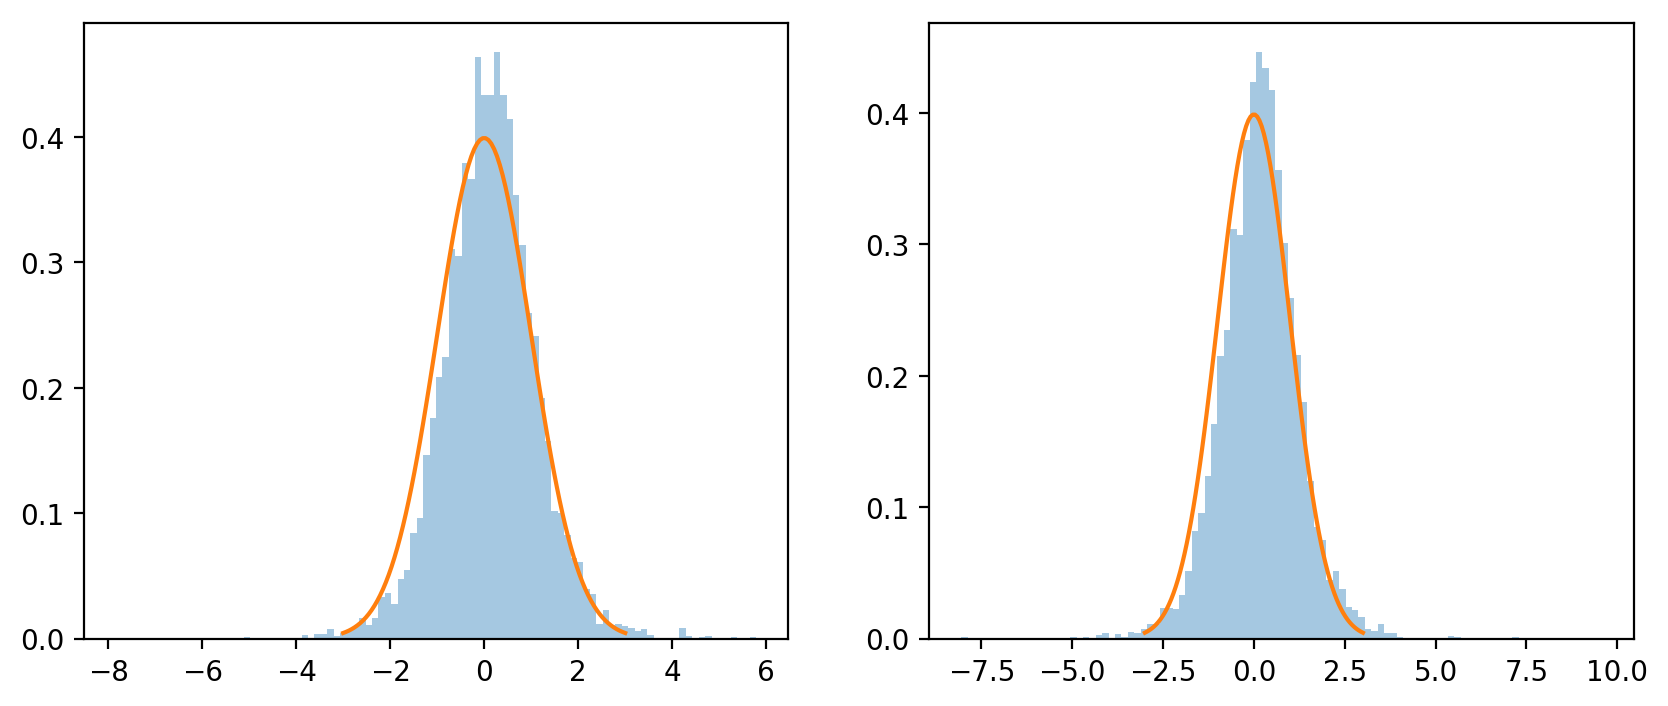

In [111]:
fig, axes = plt.subplots(1,2, figsize =(10,4))

_ = axes[0].hist((d['e1_in']-d['e1'])/d['e1_std'], bins = 100, normed = True, alpha = 0.4)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma))


_ = axes[1].hist((d['e2_in']-d['e2'])/d['e2_std'], bins = 100, normed = True, alpha = 0.4)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma))

16170
[1 2]
0 1
1 2


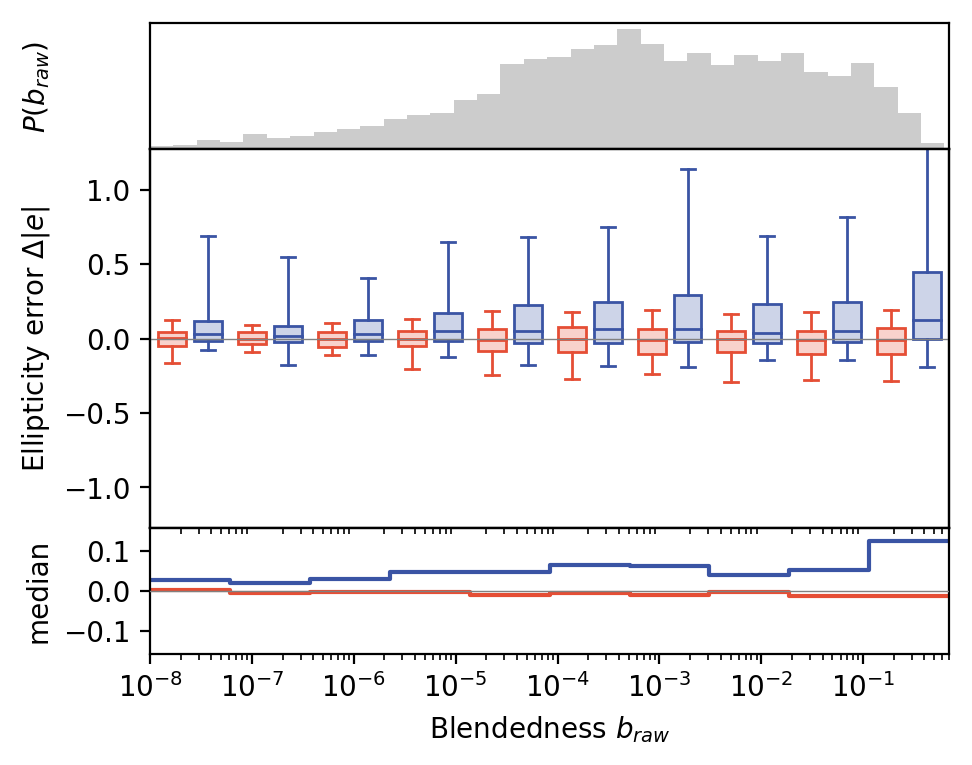

In [18]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)
fig.savefig('imgs/e_blend_dc2_ell_hsm.pdf')

16170
[1 2]
0 1
1 2


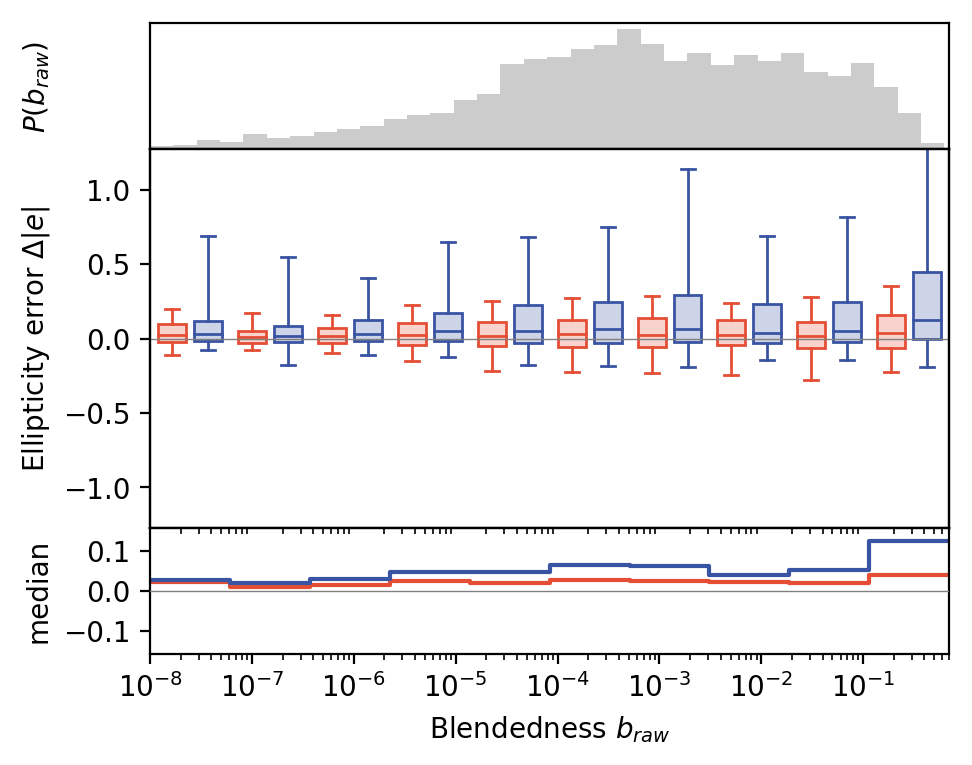

In [45]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_ell_hsm.pdf')

In [19]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [20]:
df_stat

,median_shear,q1_shear,q3_shear,whislo_shear,whishi_shear,stats_names
0,0.002540,0.049902,0.043857,0.167113,0.124032,network
1,0.006014,0.038997,0.045602,0.092486,0.090549,network
2,0.003491,0.053998,0.040526,0.110758,0.104724,network
3,0.002311,0.052367,0.049965,0.205105,0.128608,network
4,0.010190,0.081218,0.061858,0.245400,0.187294,network
5,0.006192,0.087266,0.076103,0.274523,0.180452,network
6,0.011787,0.103557,0.061876,0.237823,0.188847,network
7,0.004400,0.091269,0.051877,0.289051,0.163389,network
8,0.012061,0.101908,0.048122,0.275198,0.175076,network
9,0.013013,0.105851,0.069639,0.283426,0.194696,network


In [21]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.007199917677579921, 0.051497621612620226]
improvement between each exp: [7.152529225852192]


19974
[1 2]
0 1
1 2


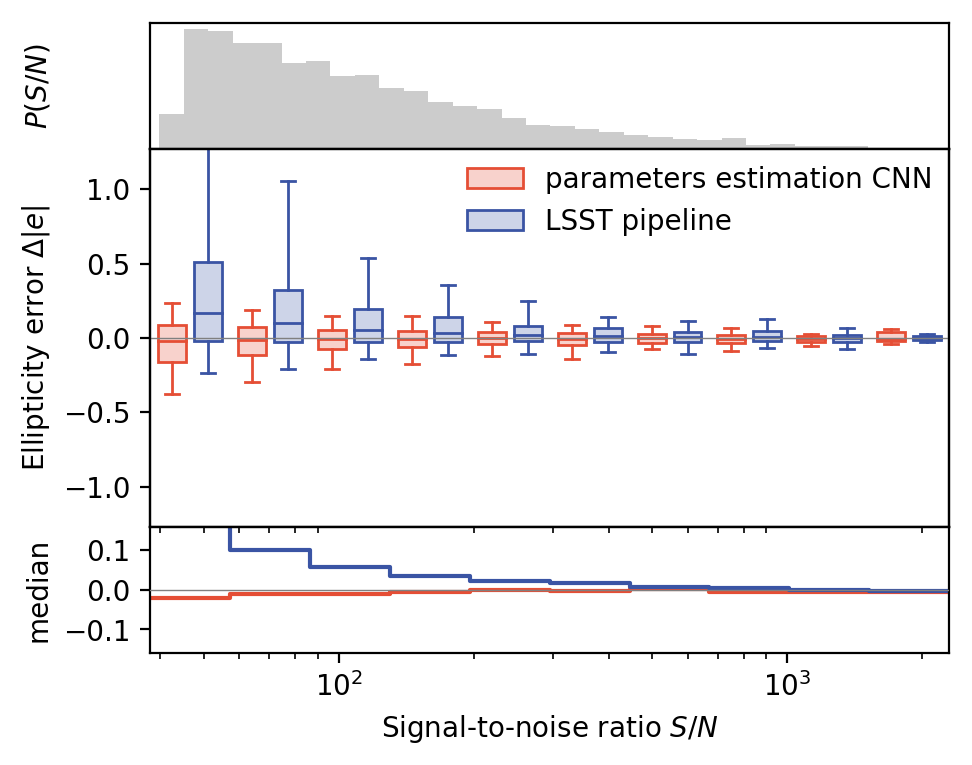

In [23]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['parameters estimation CNN', 'LSST pipeline'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

fig.savefig('imgs/e_snr_dc2_ell_hsm.pdf')

19974
[1 2]
0 1
1 2


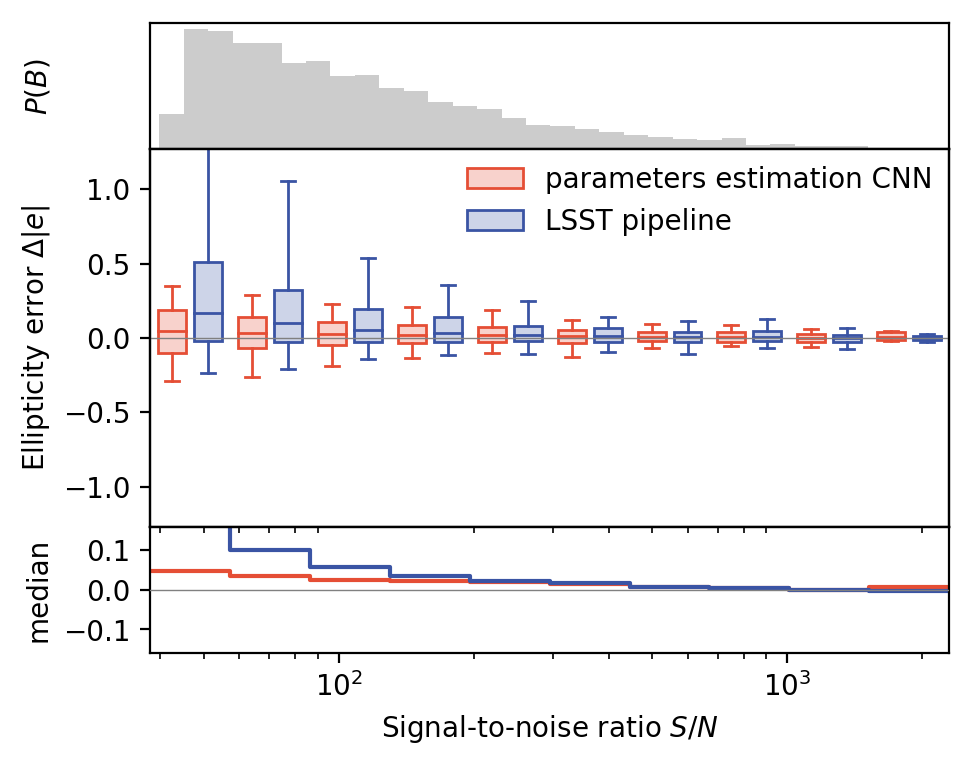

In [19]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['parameters estimation CNN', 'LSST pipeline'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_snr_dc2_ell_hsm.pdf')

In [24]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [25]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.007197978253837519, 0.04118391291670724]
improvement between each exp: [5.721594517842633]


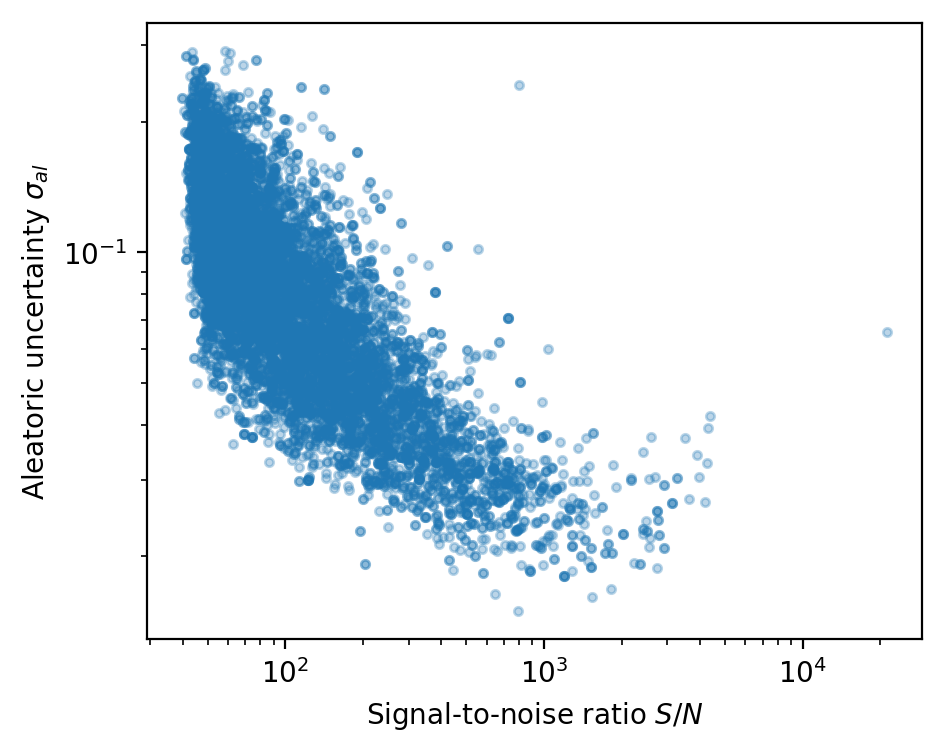

In [26]:
#plt.hist2d(data['snr_r'], d['e1_std'], bins = 10)
fig, axes = plt.subplots(1,1, figsize= (5,4))
axes.plot(data['snr_r'], d['e1_std'], '.', alpha = 0.3)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('Signal-to-noise ratio $S/N$')
axes.set_ylabel('Aleatoric uncertainty $\sigma_{al}$')

fig.savefig('imgs/sigma_al_param_ell.pdf')

Text(0.5, 1.0, '$e2$')

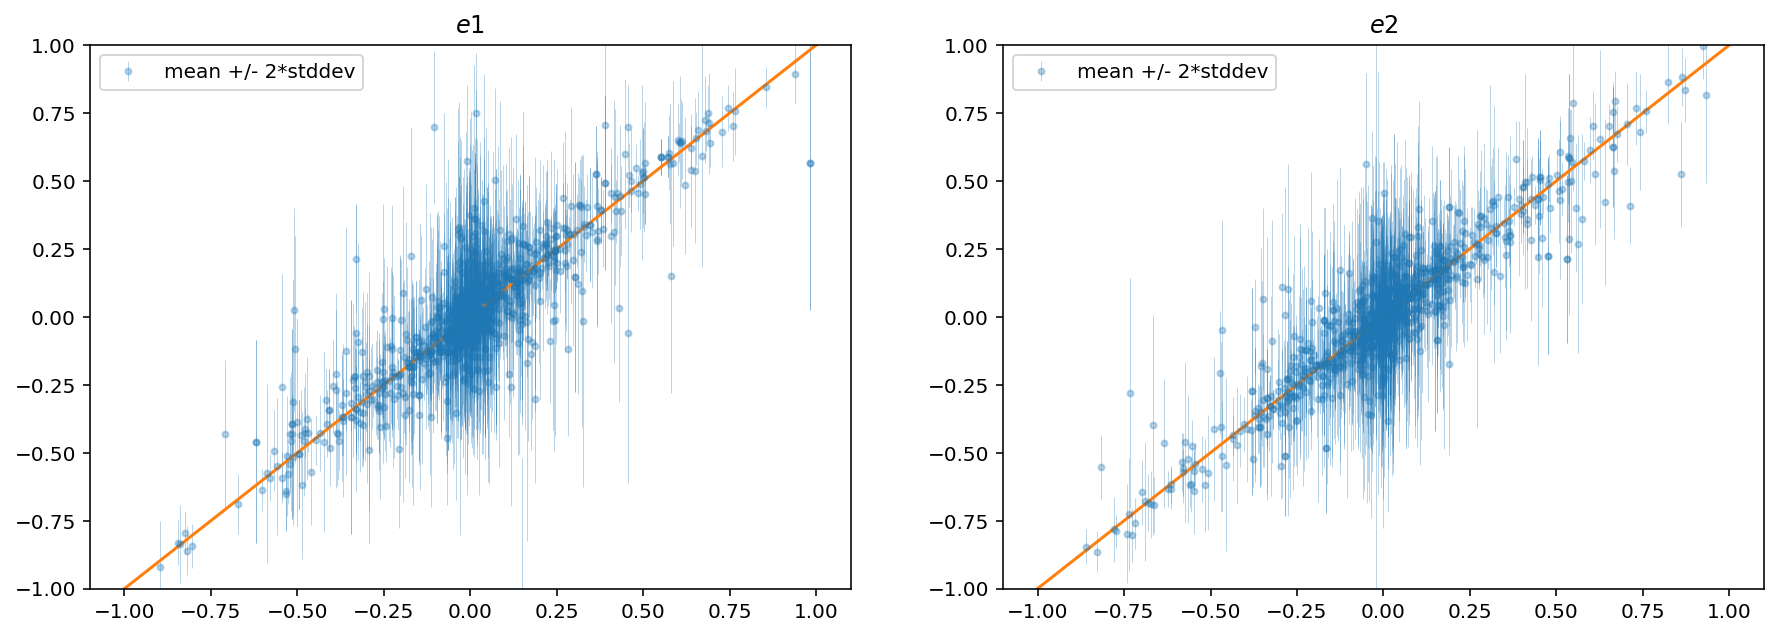

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(data['e1_lensed'][indices], -e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(data['e2_lensed'][indices], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

## Bayesian neural network

### Perform test

In [10]:
output_v1 = model_bnn([tf.cast(images[9000:10000], tf.float32), tf.cast(psf[9000:10000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

In [11]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std

df.to_csv('data/df_param_ell_bnn_4.csv')

In [112]:
part_1 = pd.read_csv('data/df_param_ell_bnn_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_bnn_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_bnn_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_bnn_4.csv', encoding = 'utf-8')

df_plot_bnn = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [113]:
part_1 = pd.read_csv('data/df_param_ell_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_4.csv', encoding = 'utf-8')

df_plot_det = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [114]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1_det'] = df_plot_det['e1_out_mean']
d['e2_det'] = df_plot_det['e2_out_mean']
d['e1_std_det'] = df_plot_det['e1_out_std']
d['e2_std_det'] = df_plot_det['e2_out_std']

d['e1_bnn'] = df_plot_bnn['e1_out_mean']
d['e2_bnn'] = df_plot_bnn['e2_out_mean']
d['e1_std_al_bnn'] = df_plot_bnn['e1_out_std']
d['e2_std_al_bnn'] = df_plot_bnn['e2_out_std']
#d['e1_std_ep_bnn'] = df_plot_bnn['e1_out_ep_std']
#d['e2_std_ep_bnn'] = df_plot_bnn['e2_out_ep_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1_det'],data['e1_hsm_regauss'],d['e1_bnn']], ignore_index = True)
df['e_2'] = pd.concat([d['e2_det'],data['e2_hsm_regauss'],d['e2_bnn']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1_det']**2+d['e2_det']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2),np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000+[3]*10000

df_plot_2 = df[df['blendedness']>0]

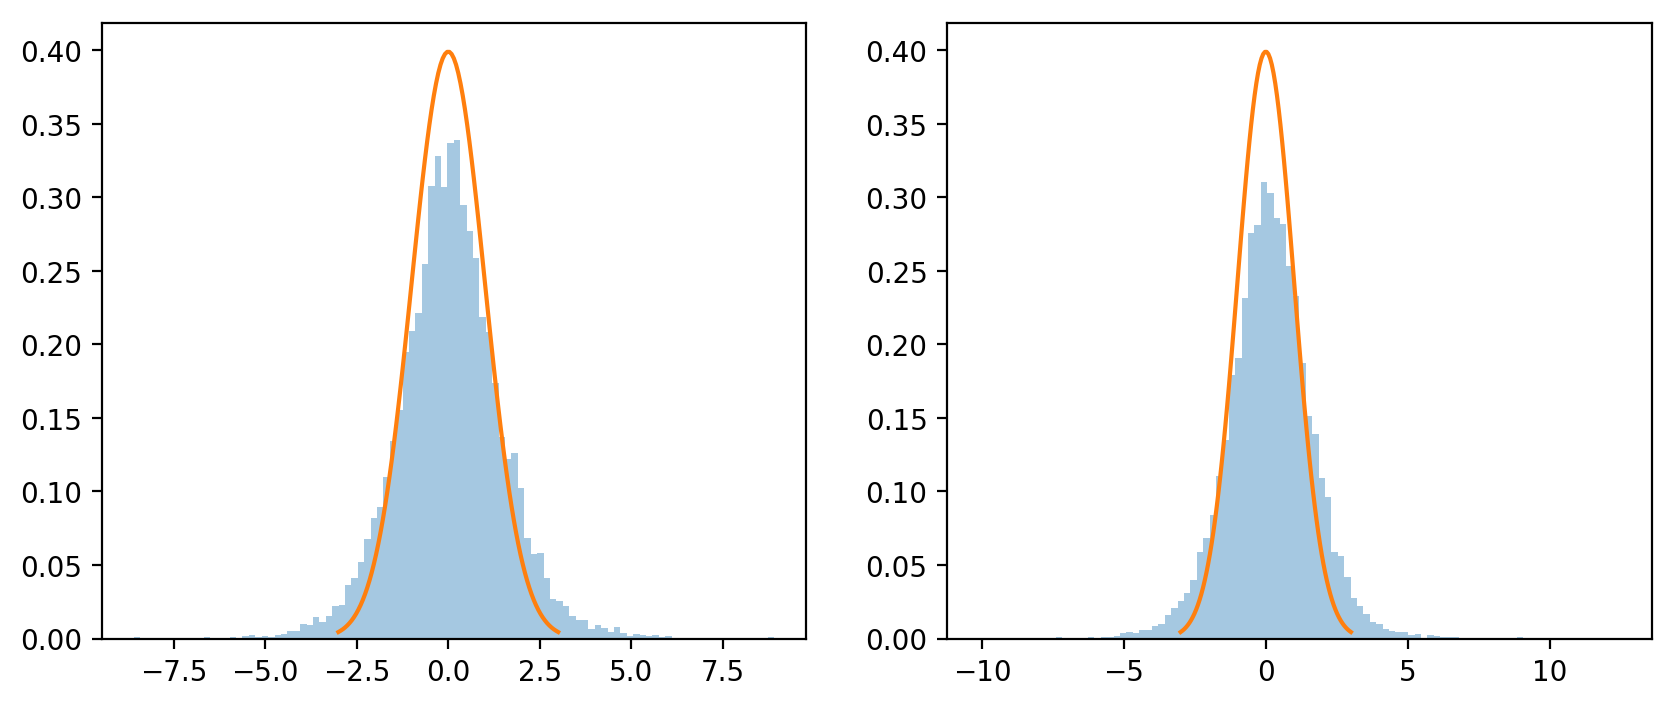

In [115]:
fig, axes = plt.subplots(1,2, figsize =(10,4))

_ = axes[0].hist((d['e1_in']-df_plot_bnn['e1_out_mean'])/df_plot_bnn['e1_out_std'], bins = 100, normed = True, alpha = 0.4)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma))


_ = axes[1].hist((d['e2_in']-df_plot_bnn['e2_out_mean'])/df_plot_bnn['e2_out_std'], bins = 100, normed = True, alpha = 0.4)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma))


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/font_manager.py:1241: UserWarning: findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
  (prop.get_family(), self.defaultFamily[fontext]))


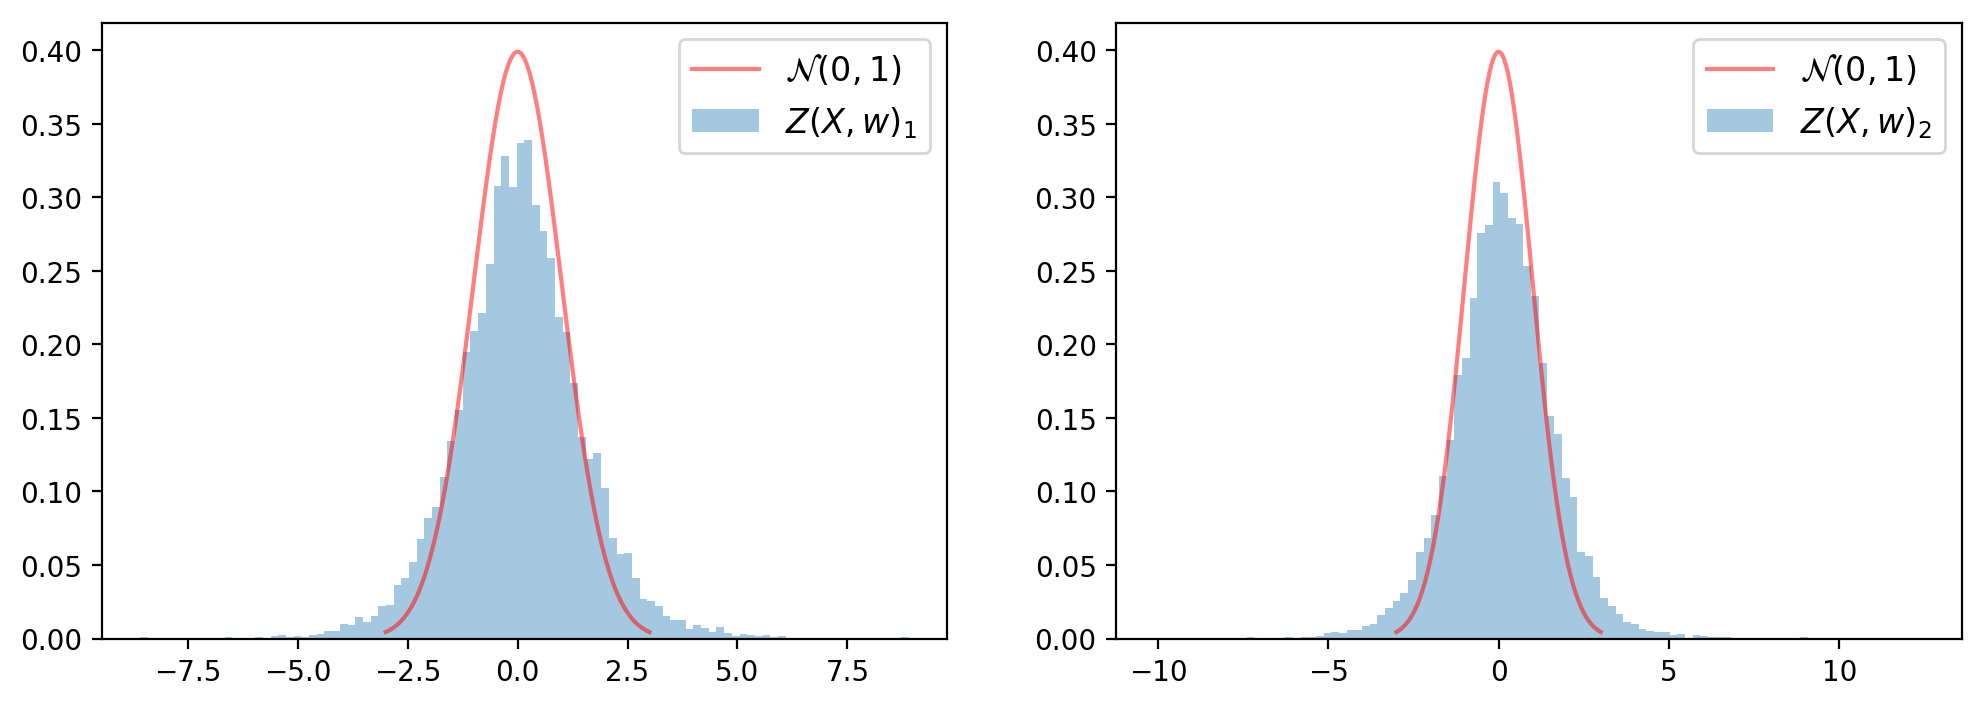

In [116]:
import matplotlib
fig, axes = plt.subplots(1,2, figsize =(12,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

_ = axes[0].hist((d['e1_in']-df_plot_bnn['e1_out_mean'])/df_plot_bnn['e1_out_std'], bins = 100, normed = True, alpha = 0.4, label='$Z(X,w)_1$')
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), label = '$\mathcal{N}(0,1)$', color = 'red', alpha = 0.5)
axes[0].legend()
#axes[0].set_title

_ = axes[1].hist((d['e2_in']-df_plot_bnn['e2_out_mean'])/df_plot_bnn['e2_out_std'], bins = 100, normed = True, alpha = 0.4, label='$Z(X,w)_2$')
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), label = '$\mathcal{N}(0,1)$', color = 'red', alpha = 0.5)
axes[1].legend()
#axes[0].set_title

fig.savefig('imgs/distrib_al_bnn.pdf')

24265
[1 2 3]
0 1
1 2
2 3


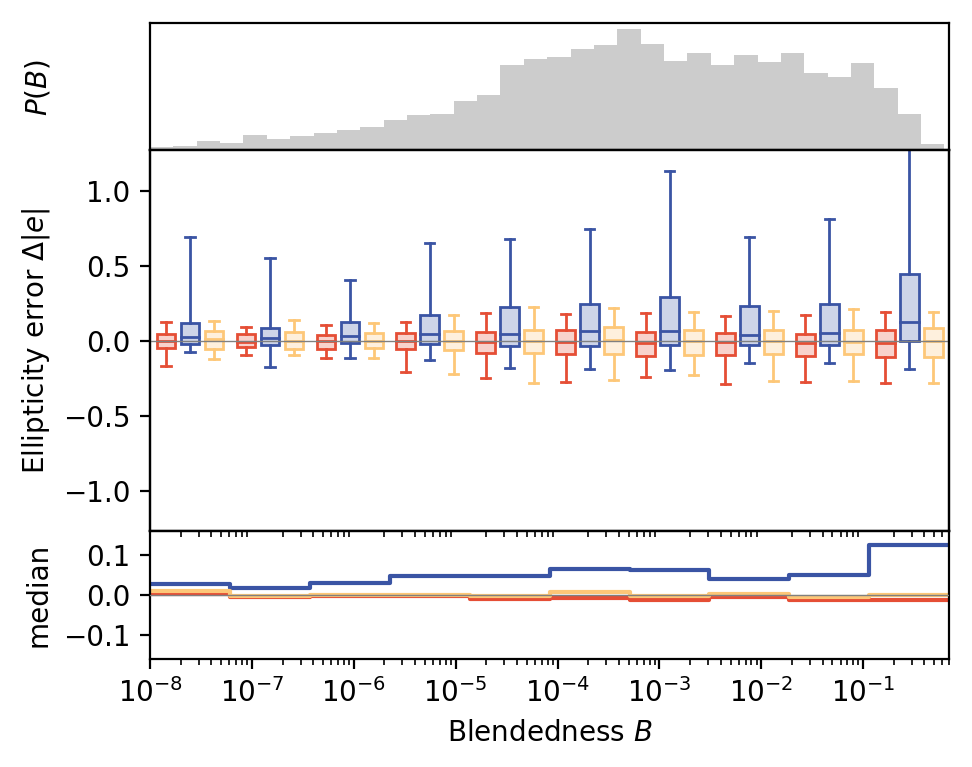

In [20]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'DebVAder', 'BNN parameters estimation'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95,0.35]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_from_vae_hsm.pdf')

24265
[1 2 3]
0 1
1 2
2 3


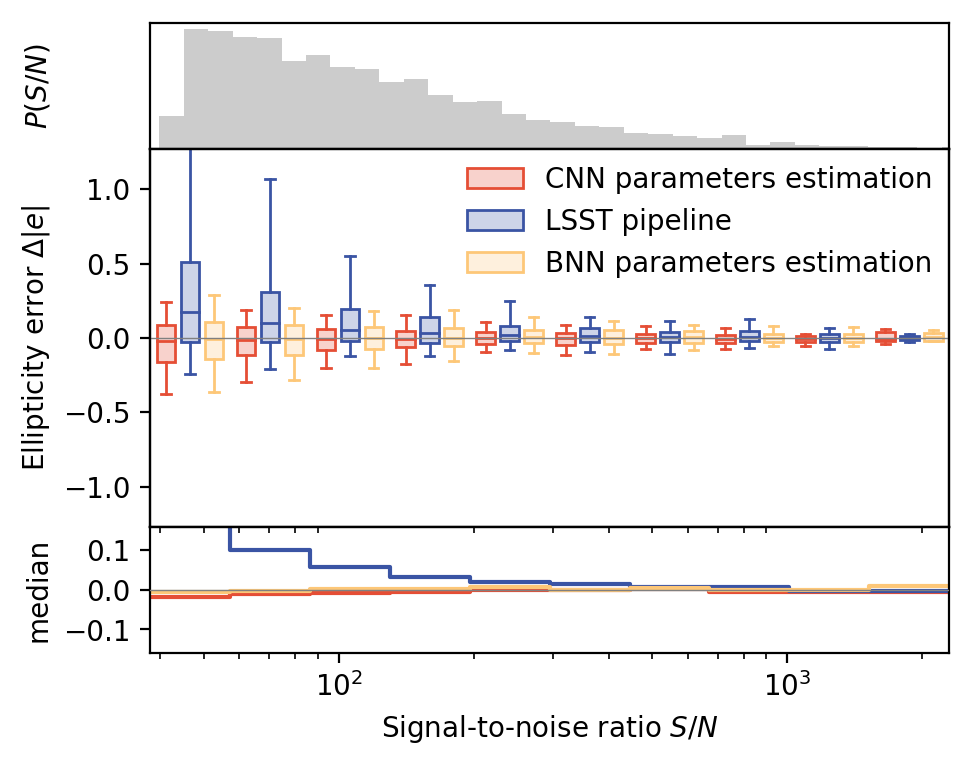

In [117]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'LSST pipeline', 'BNN parameters estimation'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15,0.95,0.35]),
              nbins = 10)

### Plots specifiques BNN

In [8]:
output_v1 = model_bnn([tf.cast(images[0:3000], tf.float32), tf.cast(psf[0:3000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

In [9]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std

df.to_csv('data/df_param_ell_bnn_spec_9.csv')

In [5]:
part_0 = pd.read_csv('data/df_param_ell_bnn_1.csv', encoding = 'utf-8')
part_1 = pd.read_csv('data/df_param_ell_bnn_spec_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_bnn_spec_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_bnn_spec_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_bnn_spec_4.csv', encoding = 'utf-8')
part_5 = pd.read_csv('data/df_param_ell_bnn_spec_5.csv', encoding = 'utf-8')
part_6 = pd.read_csv('data/df_param_ell_bnn_spec_6.csv', encoding = 'utf-8')
part_7 = pd.read_csv('data/df_param_ell_bnn_spec_7.csv', encoding = 'utf-8')
part_8 = pd.read_csv('data/df_param_ell_bnn_spec_8.csv', encoding = 'utf-8')
part_9 = pd.read_csv('data/df_param_ell_bnn_spec_9.csv', encoding = 'utf-8')

df_plot_bnn = pd.concat([part_0, part_1,part_2, part_3, part_4, part_5, part_6, part_7, part_8, part_9], ignore_index = True)

In [27]:
part_0['e1_out_mean'][0], part_1['e1_out_mean'][0], part_2['e1_out_mean'][0],part_3['e1_out_mean'][0], part_4['e1_out_mean'][0], part_5['e1_out_mean'][0]

(0.2145803, 0.19580305, 0.2366209, 0.25584644, 0.22413024, 0.28443283)

In [28]:
df_plot_bnn.shape, df_plot_bnn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
Unnamed: 0     30000 non-null int64
e1_out_mean    30000 non-null float64
e2_out_mean    30000 non-null float64
e1_out_std     30000 non-null float64
e2_out_std     30000 non-null float64
dtypes: float64(4), int64(1)
memory usage: 1.1 MB


((30000, 5), None)

In [6]:
df_plot_bnn_2 = pd.DataFrame()

df_plot_bnn_2['e1_out_mean']=np.zeros((3000))
df_plot_bnn_2['e2_out_mean']=np.zeros((3000))
df_plot_bnn_2['e1_out_al_std']=np.zeros((3000))
df_plot_bnn_2['e2_out_al_std']=np.zeros((3000))
df_plot_bnn_2['e1_out_ep_std']=np.zeros((3000))
df_plot_bnn_2['e2_out_ep_std']=np.zeros((3000))

for i in range (3000):
    df_plot_bnn_2['e1_out_mean'][i] = np.mean((df_plot_bnn['e1_out_mean'][i],df_plot_bnn['e1_out_mean'][i+3000],df_plot_bnn['e1_out_mean'][i+6000],
                                          df_plot_bnn['e1_out_mean'][i+9000],df_plot_bnn['e1_out_mean'][i+12000],df_plot_bnn['e1_out_mean'][i+15000],
                                          df_plot_bnn['e1_out_mean'][i+18000],df_plot_bnn['e1_out_mean'][i+21000],df_plot_bnn['e1_out_mean'][i+24000],
                                          df_plot_bnn['e1_out_mean'][i+27000]))
    #print()
    df_plot_bnn_2['e2_out_mean'][i] = np.mean((df_plot_bnn['e2_out_mean'][i],df_plot_bnn['e2_out_mean'][i+3000],df_plot_bnn['e2_out_mean'][i+6000],
                                          df_plot_bnn['e2_out_mean'][i+9000],df_plot_bnn['e2_out_mean'][i+12000],df_plot_bnn['e2_out_mean'][i+15000],
                                          df_plot_bnn['e2_out_mean'][i+18000],df_plot_bnn['e2_out_mean'][i+21000],df_plot_bnn['e2_out_mean'][i+24000],
                                          df_plot_bnn['e2_out_mean'][i+27000]))
    df_plot_bnn_2['e1_out_al_std'][i] = np.mean((df_plot_bnn['e1_out_std'][i],df_plot_bnn['e1_out_std'][i+3000],df_plot_bnn['e1_out_std'][i+6000],
                                          df_plot_bnn['e1_out_std'][i+9000],df_plot_bnn['e1_out_std'][i+12000],df_plot_bnn['e1_out_std'][i+15000],
                                          df_plot_bnn['e1_out_std'][i+18000],df_plot_bnn['e1_out_std'][i+21000],df_plot_bnn['e1_out_std'][i+24000],
                                          df_plot_bnn['e1_out_std'][i+27000]))
    df_plot_bnn_2['e2_out_al_std'][i] = np.mean((df_plot_bnn['e2_out_std'][i],df_plot_bnn['e2_out_std'][i+3000],df_plot_bnn['e2_out_std'][i+6000],
                                          df_plot_bnn['e2_out_std'][i+9000],df_plot_bnn['e2_out_std'][i+12000],df_plot_bnn['e2_out_std'][i+15000],
                                          df_plot_bnn['e2_out_std'][i+18000],df_plot_bnn['e2_out_std'][i+21000],df_plot_bnn['e2_out_std'][i+24000],
                                          df_plot_bnn['e2_out_std'][i+27000]))
    df_plot_bnn_2['e1_out_ep_std'][i] = np.std((df_plot_bnn['e1_out_mean'][i],df_plot_bnn['e1_out_mean'][i+3000],df_plot_bnn['e1_out_mean'][i+6000],
                                          df_plot_bnn['e1_out_mean'][i+9000],df_plot_bnn['e1_out_mean'][i+12000],df_plot_bnn['e1_out_mean'][i+15000],
                                          df_plot_bnn['e1_out_mean'][i+18000],df_plot_bnn['e1_out_mean'][i+21000],df_plot_bnn['e1_out_mean'][i+24000],
                                          df_plot_bnn['e1_out_mean'][i+27000]))
    df_plot_bnn_2['e2_out_ep_std'][i] = np.std((df_plot_bnn['e2_out_mean'][i],df_plot_bnn['e2_out_mean'][i+3000],df_plot_bnn['e2_out_mean'][i+6000],
                                          df_plot_bnn['e2_out_mean'][i+9000],df_plot_bnn['e2_out_mean'][i+12000],df_plot_bnn['e2_out_mean'][i+15000],
                                          df_plot_bnn['e2_out_mean'][i+18000],df_plot_bnn['e2_out_mean'][i+21000],df_plot_bnn['e2_out_mean'][i+24000],
                                          df_plot_bnn['e2_out_mean'][i+27000]))

In [7]:
part_1 = pd.read_csv('data/df_param_ell_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_4.csv', encoding = 'utf-8')

df_plot_det = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [10]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1_det'] = df_plot_det['e1_out_mean'][:3000]
d['e2_det'] = df_plot_det['e2_out_mean'][:3000]
d['e1_std_det'] = df_plot_det['e1_out_std'][:3000]
d['e2_std_det'] = df_plot_det['e2_out_std'][:3000]

d['e1_bnn'] = df_plot_bnn_2['e1_out_mean']
d['e2_bnn'] = df_plot_bnn_2['e2_out_mean']
d['e1_std_al_bnn'] = df_plot_bnn_2['e1_out_al_std']
d['e2_std_al_bnn'] = df_plot_bnn_2['e2_out_al_std']
d['e1_std_ep_bnn'] = df_plot_bnn_2['e1_out_ep_std']
d['e2_std_ep_bnn'] = df_plot_bnn_2['e2_out_ep_std']
d['e1_in'] = -e1[:3000]
d['e2_in'] = e2[:3000]
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1_det'],data['e1_hsm_regauss'][:3000],d['e1_bnn']], ignore_index = True)
df['e_2'] = pd.concat([d['e2_det'],data['e2_hsm_regauss'][:3000],d['e2_bnn']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1_det']**2+d['e2_det']**2),np.sqrt(data['e1_hsm_regauss'][:3000]**2+data['e2_hsm_regauss'][:3000]**2),np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']

df['blendedness'] = pd.concat([data['blendedness'][:3000],data['blendedness'][:3000],data['blendedness'][:3000]], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'][:3000],data['snr_r'][:3000],data['snr_r'][:3000]], ignore_index = True)

df['exp'] = [1]*3000+[2]*3000+[3]*3000

df_plot_2 = df[df['blendedness']>0]

7263
[1 2 3]
0 1
1 2
2 3


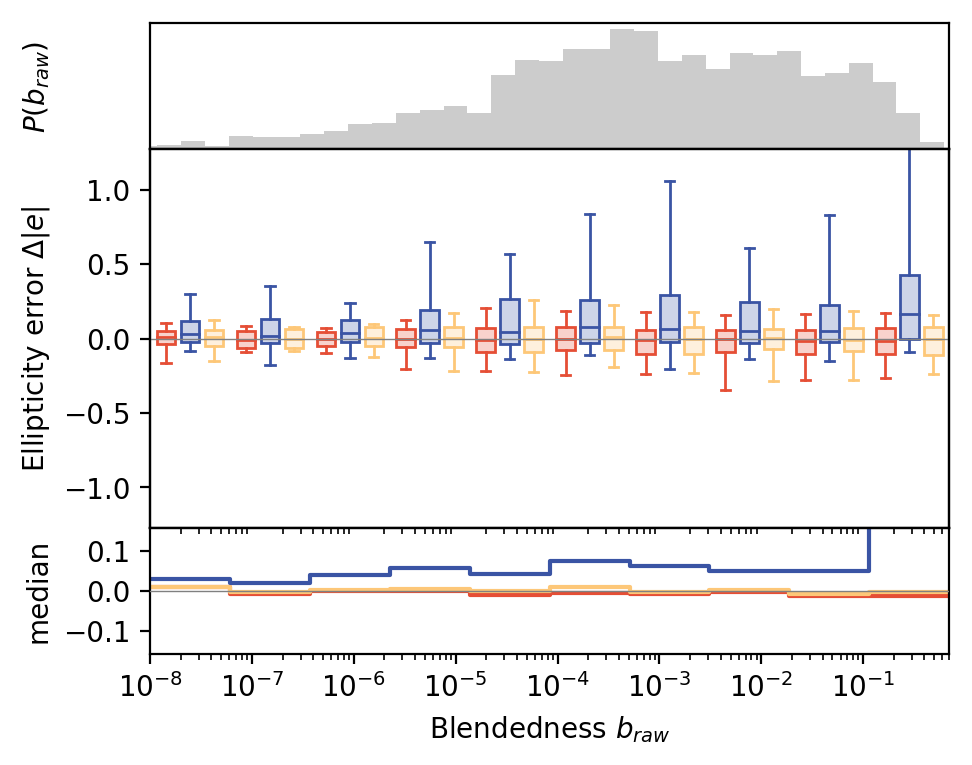

In [134]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'DebVAder', 'BNN parameters estimation'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95,0.35]),
              nbins = 10)

fig.savefig('imgs/e_blend_dc2_bnn.pdf')

In [124]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10+ ['bnn']*10

x = 10

In [126]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]), np.mean(df_stat[param][:+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.007380872295055021, 0.0586576176271008, 0.004841195464524361]
improvement between each exp: [7.947247328259529, 1.524597044085717]


7263
[1 2 3]
0 1
1 2
2 3


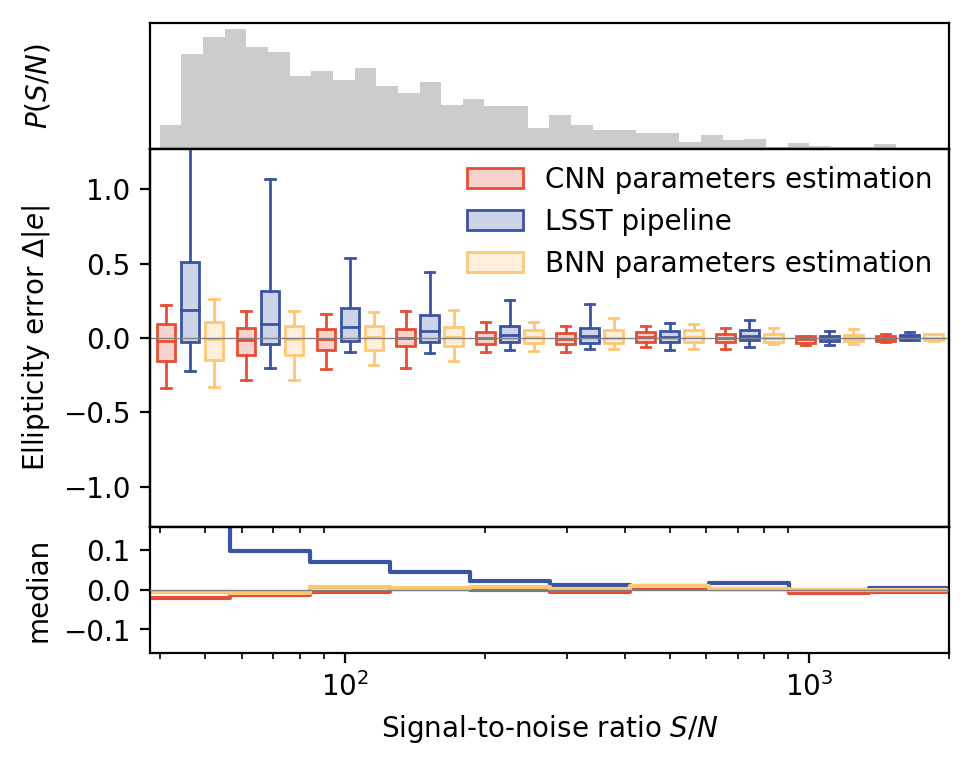

In [55]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2000),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'LSST pipeline', 'BNN parameters estimation'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95, 0.35]),
              nbins = 10)
fig.savefig('imgs/e_snr_dc2_bnn.pdf')

In [128]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10+ ['bnn']*10

x = 10

In [129]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]), np.mean(df_stat[param][:+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.008135917814102092, 0.04415552774918094, 0.005011237300377222]
improvement between each exp: [5.427233750154849, 1.6235347333261705]


In [36]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1_det'] = df_plot_det['e1_out_mean'][:3000]
d['e2_det'] = df_plot_det['e2_out_mean'][:3000]
d['e1_std_det'] = df_plot_det['e1_out_std'][:3000]
d['e2_std_det'] = df_plot_det['e2_out_std'][:3000]

d['e1_bnn'] = df_plot_bnn_2['e1_out_mean']
d['e2_bnn'] = df_plot_bnn_2['e2_out_mean']
d['e1_std_al_bnn'] = df_plot_bnn_2['e1_out_al_std']
d['e2_std_al_bnn'] = df_plot_bnn_2['e2_out_al_std']
d['e1_std_ep_bnn'] = df_plot_bnn_2['e1_out_ep_std']
d['e2_std_ep_bnn'] = df_plot_bnn_2['e2_out_ep_std']
d['e1_in'] = -e1[:3000]
d['e2_in'] = e2[:3000]
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1_det'],d['e1_bnn']], ignore_index = True)
df['e_2'] = pd.concat([d['e2_det'],d['e2_bnn']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1_det']**2+d['e2_det']**2),np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']

df['blendedness'] = pd.concat([data['blendedness'][:3000],data['blendedness'][:3000]], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'][:3000],data['snr_r'][:3000]], ignore_index = True)

df['exp'] = [1]*3000+[2]*3000

df_plot_2 = df[df['blendedness']>0]

4844
[1 2]
0 1
1 2


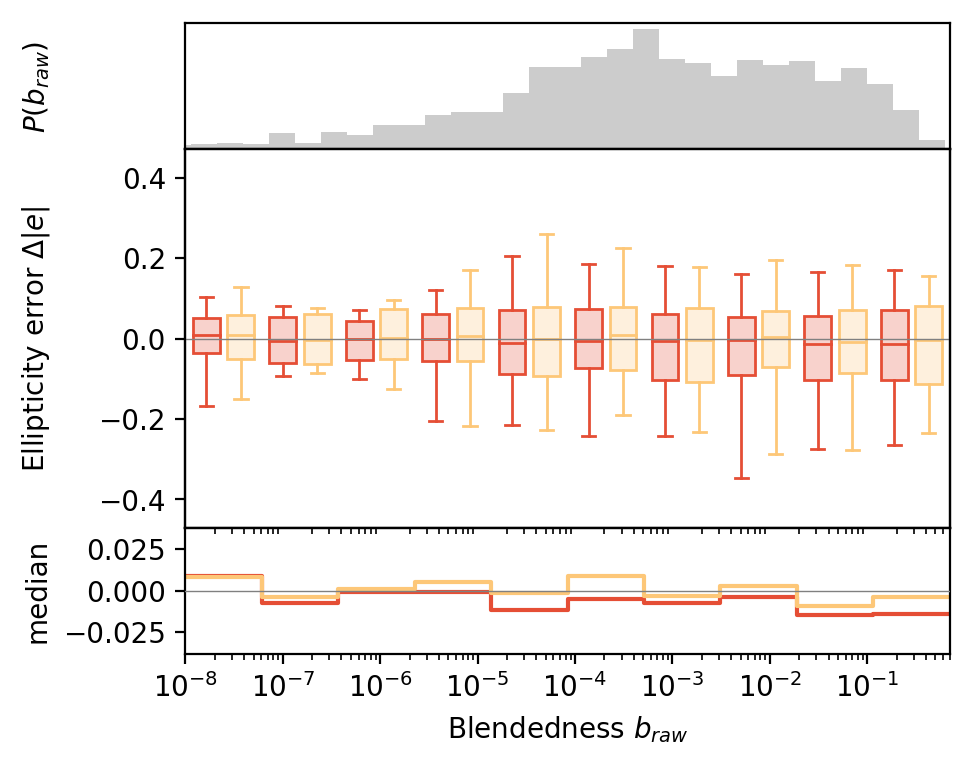

In [45]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-.47, .47),
              ylim2= (-0.038, 0.038),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'BNN parameters estimation'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.35]),
              nbins = 10)


fig.savefig('imgs/e_blend_dc2_bnn_2.pdf')

In [47]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 +  ['bnn']*10

x = 10

In [ ]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:+x])/np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][:+x])/np.mean(df_stat[param][20:20+x])]))

4844
[1 2]
0 1
1 2


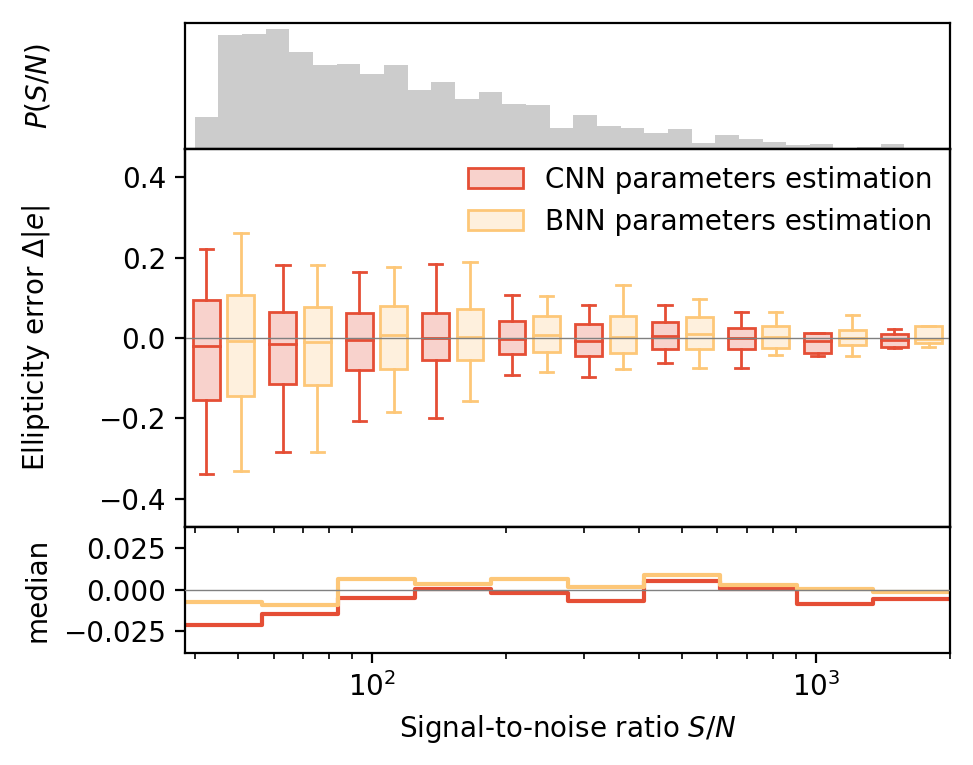

In [44]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2000),
              ylim = (-0.47, 0.47),
              ylim2= (-0.038, 0.038),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'BNN parameters estimation'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.35]),
              nbins = 10)
fig.savefig('imgs/e_snr_dc2_bnn_2.pdf')

In [50]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 +  ['bnn']*10

x = 10

In [51]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:+x])/np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][:+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.007380872295055021, 0.004841195464524361, nan]
improvement between each exp: [1.524597044085717, nan]


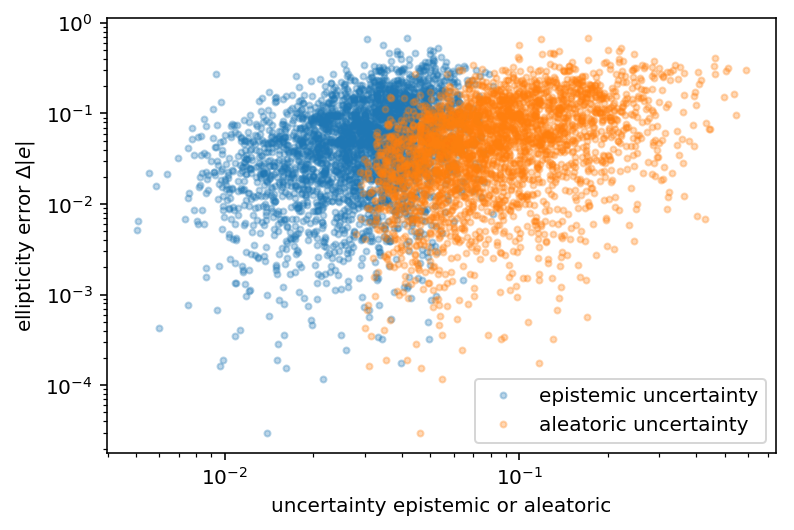

In [51]:
plt.plot(np.sqrt(d['e1_std_ep_bnn']**2+d['e2_std_ep_bnn']**2),np.abs(df['e_error_reg'][6000:9000]),  '.', alpha = 0.3 , label = 'epistemic uncertainty')
plt.plot(np.sqrt(d['e1_std_al_bnn']**2+d['e2_std_al_bnn']**2),np.abs(df['e_error_reg'][6000:9000]),  '.', alpha = 0.3 , label = 'aleatoric uncertainty')
plt.yscale('log')
plt.xscale('log')

plt.xlabel('uncertainty epistemic or aleatoric')
plt.ylabel('ellipticity error $\Delta |e|$')
plt.legend()

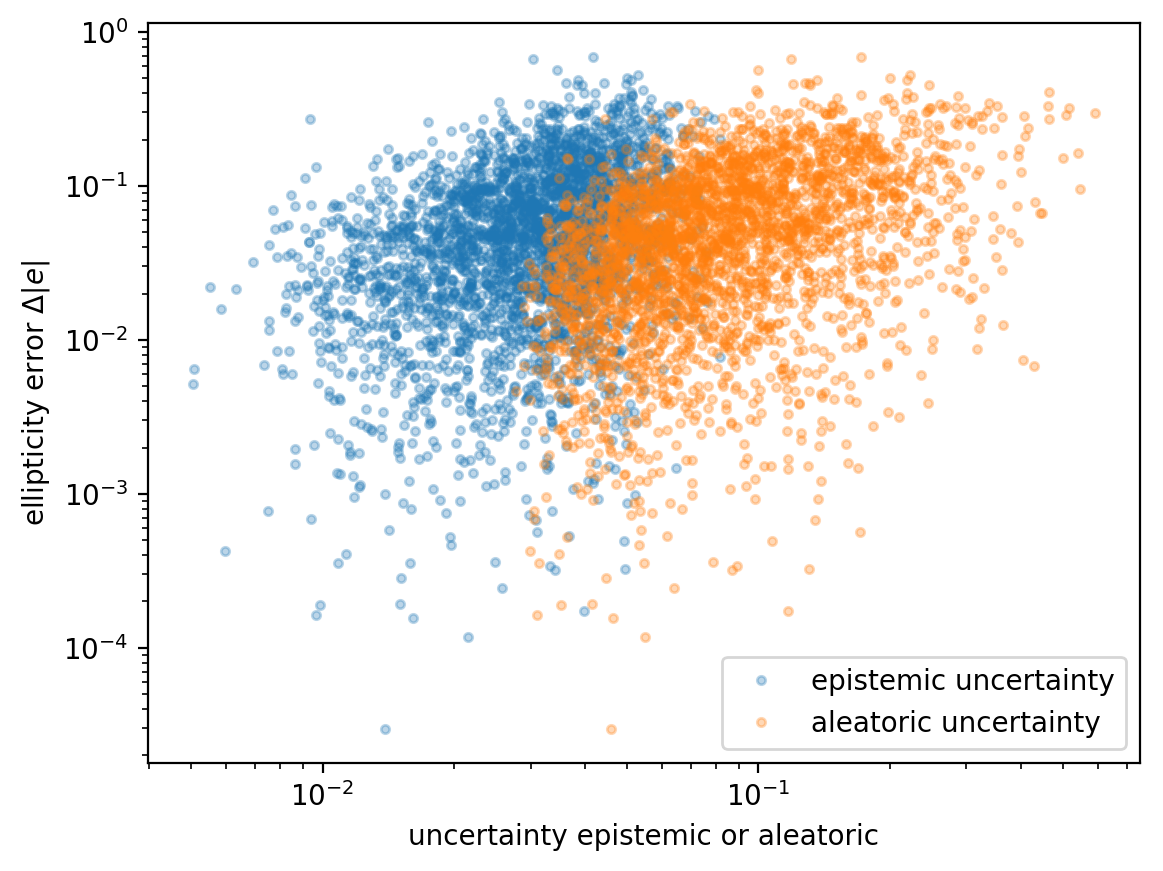

In [17]:
plt.plot(np.sqrt(d['e1_std_ep_bnn']**2+d['e2_std_ep_bnn']**2),np.abs(df['e_error_reg'][6000:9000]),  '.', alpha = 0.3 , label = 'epistemic uncertainty')
plt.plot(np.sqrt(d['e1_std_al_bnn']**2+d['e2_std_al_bnn']**2),np.abs(df['e_error_reg'][6000:9000]),  '.', alpha = 0.3 , label = 'aleatoric uncertainty')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('uncertainty epistemic or aleatoric')
plt.ylabel('ellipticity error $\Delta |e|$')
plt.legend()

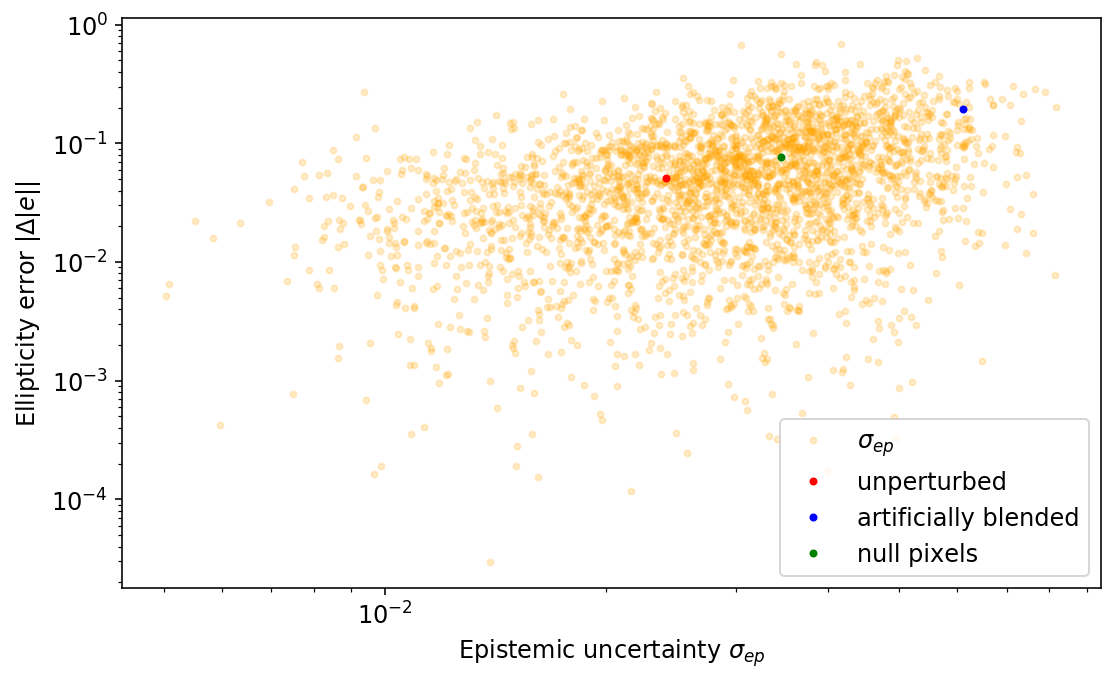

In [96]:
import matplotlib
#fig, axes = plt.subplots(1,2, figsize =(12,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

fig, ax = plt.subplots(1,1,figsize = (8,5))
ax.plot(np.sqrt(d['e1_std_ep_bnn']**2+d['e2_std_ep_bnn']**2),np.abs(df['e_error_reg'][6000:9000]),  '.', color = 'orange', alpha = 0.2, label = '$\sigma_{ep}$')
#plt.plot(np.sqrt(d['e1_std_al_bnn']**2+d['e2_std_al_bnn']**2),np.abs(df['e_error_reg'][6000:9000]),  '.', alpha = 0.3 , label = 'aleatoric uncertainty')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Epistemic uncertainty $\sigma_{ep}$')
ax.set_ylabel('Ellipticity error $|\Delta |e||$')

y = [0.05126537807017848, 0.19512601424276546, 0.07604250456869885]
x = [0.024066526, 0.061118543, 0.03458405]
ax.plot(x[0],y[0], '.', color = 'r', label = 'unperturbed')
ax.plot(x[1],y[1], '.', color = 'blue', label = 'artificially blended')
ax.plot(x[2],y[2], '.', color = 'green', label = 'null pixels')

ax.legend()
fig.tight_layout()
fig.savefig('imgs/error_vs_epistemic.pdf')

In [59]:
x = np.linspace(-6,6,1000)

def sigmoid(x):
    return (1/(1+np.exp(-x)))

def tanh(x):
    return ((2/(1+np.exp(-2*x)))-1)

def relu(x):
    return np.piecewise(x, [x < 0, x >= 0], [lambda x: 0, lambda x: x])

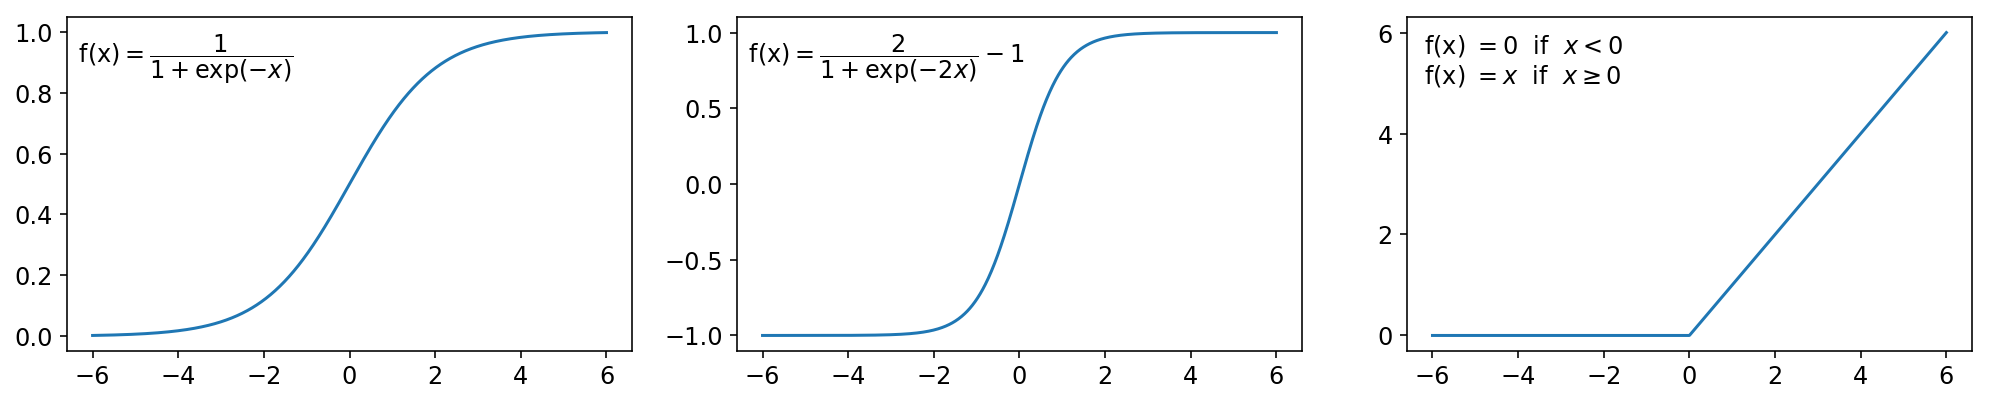

In [95]:
import matplotlib
#fig, axes = plt.subplots(1,2, figsize =(12,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

fig, ax = plt.subplots(1,3,figsize = (14,3))

ax[0].plot(x, sigmoid(x))#, color = 'b')
ax[0].text(-6.5,.9, " f(x)$= \dfrac{1}{1+\exp(-x)}$")
ax[1].plot(x, tanh(x))
ax[1].text(-6.5,.8, " f(x)$= \dfrac{2}{1+\exp(-2x)} -1$")
ax[2].plot(x, relu(x))
ax[2].text(-6.2,5., "f(x) $= 0$  if  $x<0$\nf(x) $= x$  if  $x\geq0$")

fig.tight_layout()
fig.savefig('imgs/activ_functions.pdf')

In [160]:


d = pd.DataFrame()
d['e1_det'] = df_plot_det['e1_out_mean'][:3000]
d['e2_det'] = df_plot_det['e2_out_mean'][:3000]
d['e1_std_det'] = df_plot_det['e1_out_std'][:3000]
d['e2_std_det'] = df_plot_det['e2_out_std'][:3000]

d['e1_bnn'] = df_plot_bnn_2['e1_out_mean']
d['e2_bnn'] = df_plot_bnn_2['e2_out_mean']
d['e1_std_al_bnn'] = df_plot_bnn_2['e1_out_al_std']
d['e2_std_al_bnn'] = df_plot_bnn_2['e2_out_al_std']
d['e1_std_ep_bnn'] = df_plot_bnn_2['e1_out_ep_std']
d['e2_std_ep_bnn'] = df_plot_bnn_2['e2_out_ep_std']
d['e1_in'] = -e1[:3000]
d['e2_in'] = e2[:3000]
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

In [189]:
#df_cut = pd.DataFrame()
d_cut = pd.DataFrame()
d_cut = d[np.sqrt(d['e1_std_ep_bnn']**2+d['e2_std_ep_bnn']**2)<0.049]
print(len(d_cut))

e_cut = np.sqrt(d_cut['e1_bnn']**2+d_cut['e2_bnn']**2)
e_no_cut = np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)
mean_error_cut = np.mean(e_cut)

print(np.mean(e_cut), np.mean(e_no_cut))

2698
0.24016271460103972 0.25745097642287074


In [190]:
0.25745097642287074/0.24016271460103972

1.0719856196268869

In [196]:
0.24016271460103972/0.25745097642287074

0.9328483346148412

In [194]:
#df_cut = pd.DataFrame()
d_cut = pd.DataFrame()
d_cut = d[np.sqrt(d['e1_std_al_bnn']**2+d['e2_std_al_bnn']**2)<0.178]
print(len(d_cut))

e_cut = np.sqrt(d_cut['e1_bnn']**2+d_cut['e2_bnn']**2)
e_no_cut = np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)
mean_error_cut = np.mean(e_cut)

print(np.mean(e_cut), np.mean(e_no_cut))

2700
0.2526966618884355 0.25745097642287074


In [195]:
0.25745097642287074/0.2526966618884355

1.0188143147555082

In [201]:
d_cut_2 = pd.DataFrame()
d_cut_2 = d[np.sqrt(d['e1_std_ep_bnn']**2+d['e2_std_ep_bnn']**2+d['e1_std_al_bnn']**2+d['e2_std_al_bnn']**2)<0.183]
print(len(d_cut_2))

e_cut = np.sqrt(d_cut_2['e1_bnn']**2+d_cut_2['e2_bnn']**2)
e_no_cut = np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)
#mean_error_cut = np.mean(e_cut)

print(np.mean(e_cut), np.mean(e_no_cut))

2698
0.25222462754183905 0.25745097642287074


In [202]:
0.25745097642287074/0.25222462754183905

1.0207210094112034

In [172]:
df_cut

,e,e_in,e_error_reg
0,0.650373,0.680509,-0.030135
1,0.005417,0.152278,-0.146861
2,0.518469,0.530873,-0.012404
3,0.566775,0.627673,-0.060898
4,0.051576,0.014088,0.037488
5,0.435453,0.130082,0.305372
6,0.059462,0.181489,-0.122027
7,0.189090,0.226980,-0.037889
8,0.064913,0.093567,-0.028654
9,0.361127,0.337786,0.023341


4844
[1 2]
0 1
1 2


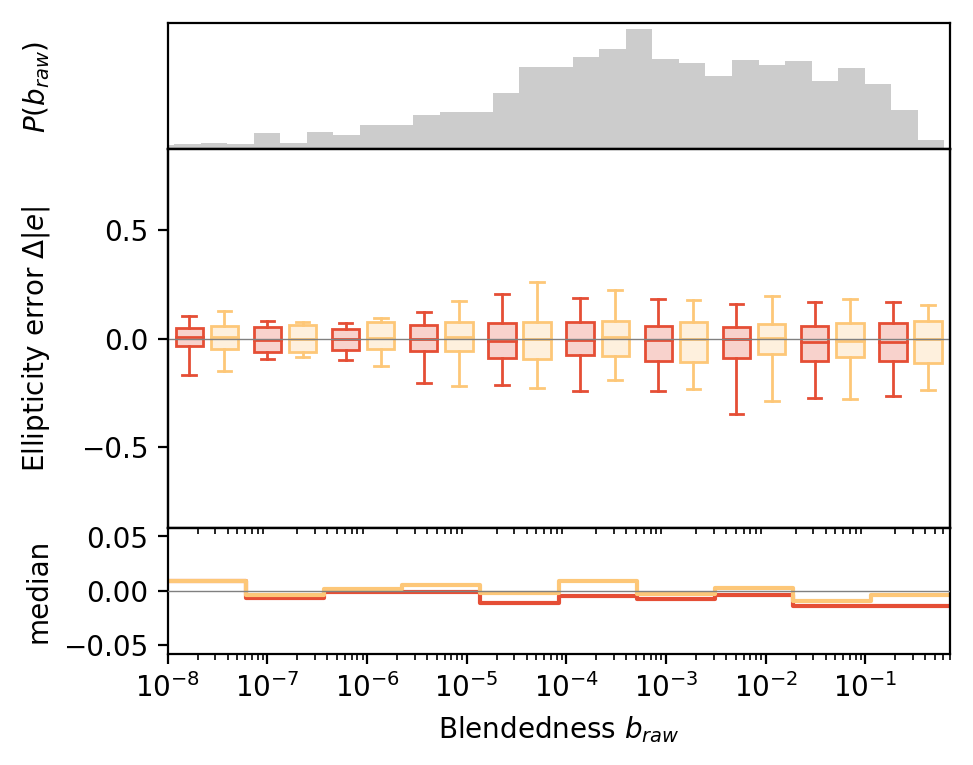

In [158]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_cut_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-0.87, 0.87),
              ylim2= (-0.058, 0.058),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'BNN parameters estimation'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.35]),
              nbins = 10)

fig.savefig('imgs/e_blend_dc2_bnn_cut.pdf')

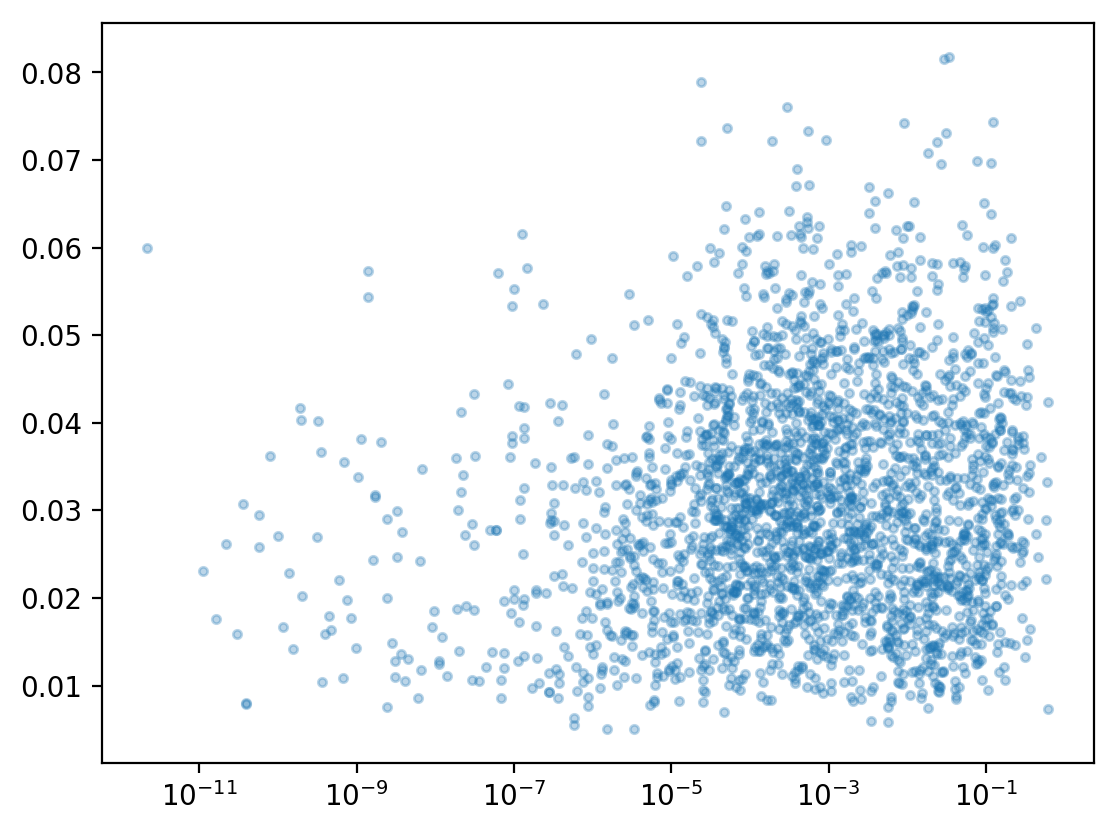

In [54]:
plt.plot(np.abs(data['blendedness'][:3000]), np.sqrt(d['e1_std_ep_bnn']**2+d['e2_std_ep_bnn']**2), '.', alpha = 0.3 , label = 'epistemic uncertainty')
plt.xscale('log')

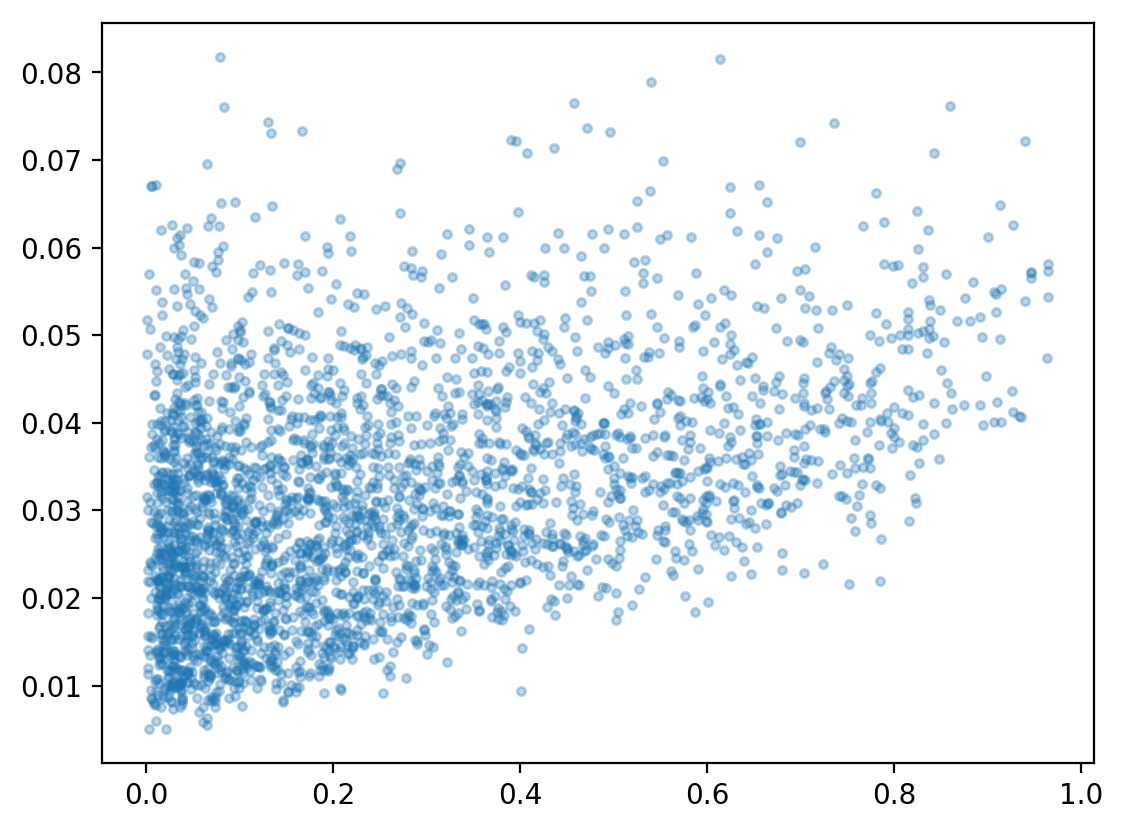

In [52]:
plt.plot(d['e_in'], np.sqrt(d['e1_std_ep_bnn']**2+d['e2_std_ep_bnn']**2), '.', alpha = 0.3 , label = 'epistemic uncertainty')
#plt.xscale('log')


<ErrorbarContainer object of 3 artists>

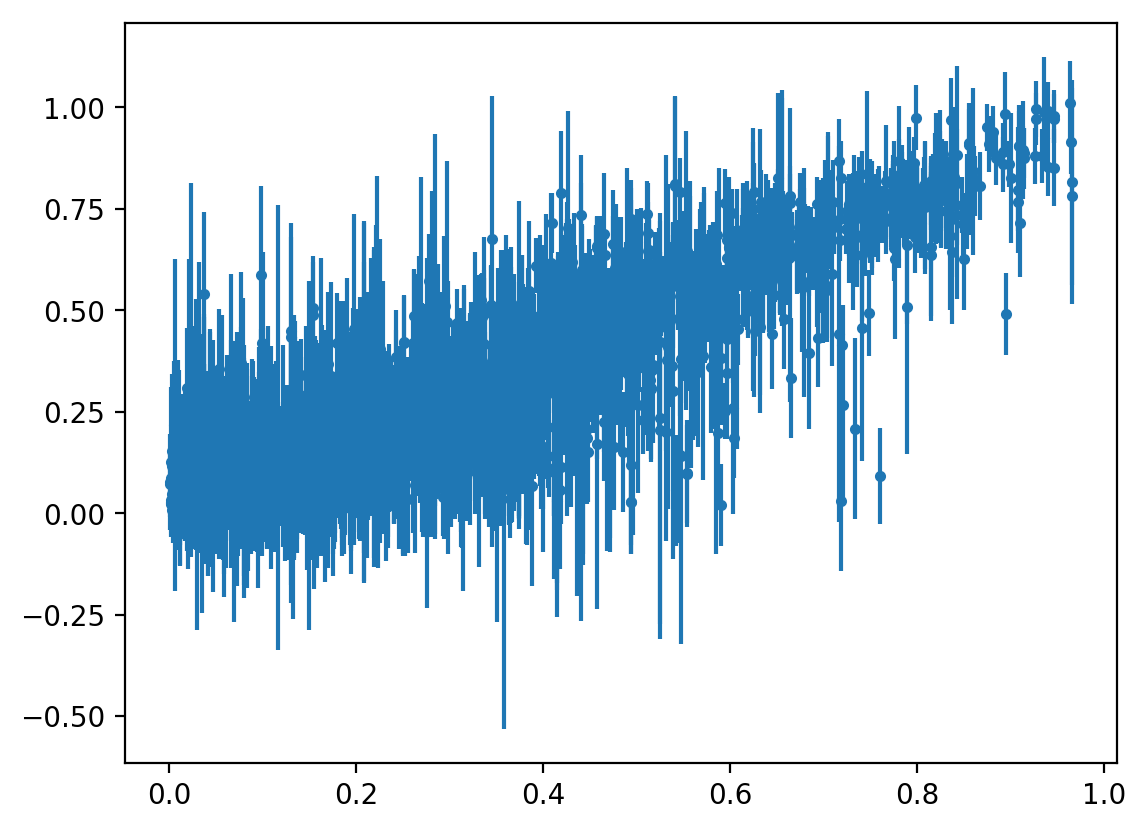

In [100]:
plt.errorbar(d['e_in'], np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2), yerr = np.sqrt(d['e1_std_al_bnn']**2+d['e2_std_al_bnn']**2),fmt= '.')

In [69]:
df_plot_bnn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
Unnamed: 0     30000 non-null int64
e1_out_mean    30000 non-null float64
e2_out_mean    30000 non-null float64
e1_out_std     30000 non-null float64
e2_out_std     30000 non-null float64
dtypes: float64(4), int64(1)
memory usage: 1.1 MB


In [95]:
fit = []

for i in range (10):
    fit.append(np.polyfit(d['e_in'][:3000], np.sqrt(df_plot_bnn['e1_out_mean'][i*3000:(i+1)*3000]**2+df_plot_bnn['e2_out_mean'][i*3000:(i+1)*3000]**2), deg=4))

In [96]:
fit

[array([ 1.45835629, -3.27975486,  2.60161228,  0.13754388,  0.07205161]),
 array([ 0.87794007, -2.24002746,  2.01649825,  0.2433342 ,  0.06927337]),
 array([ 0.80991438, -2.17342385,  2.01112798,  0.24057486,  0.06824657]),
 array([ 0.90261111, -2.33324237,  2.0974419 ,  0.22560431,  0.06843422]),
 array([ 1.1121179 , -2.71210325,  2.302906  ,  0.19161569,  0.06985625]),
 array([ 0.86583329, -2.27522734,  2.06891817,  0.22908973,  0.06896711]),
 array([ 0.87638908, -2.29938873,  2.09959846,  0.21686438,  0.07023905]),
 array([ 0.99982878, -2.51156441,  2.20341445,  0.20051863,  0.07090333]),
 array([ 1.05658608, -2.61996576,  2.2672918 ,  0.1908652 ,  0.07018829]),
 array([ 0.93095044, -2.47745679,  2.22185189,  0.1992358 ,  0.06955828])]

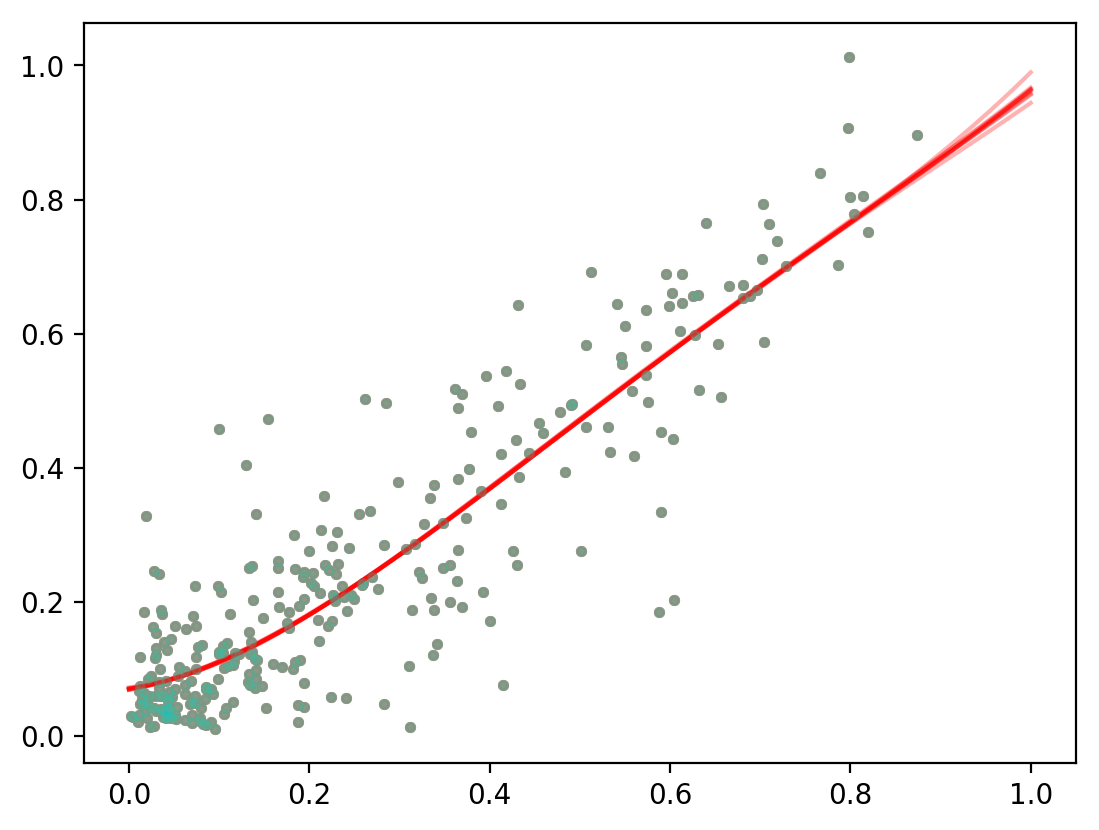

In [99]:
x = np.linspace(0,1, 1000)
for i in range(10):
    plt.plot(d['e_in'][:300], np.sqrt(df_plot_bnn['e1_out_mean'][:300]**2+df_plot_bnn['e2_out_mean'][:300]**2), fmt= '.', alpha = 0.2)
    plt.plot(x, fit[i][0]*x**4+fit[i][1]*x**3+fit[i][2]*x**2+fit[i][3]*x+fit[i][4], color = 'red', alpha = 0.3)

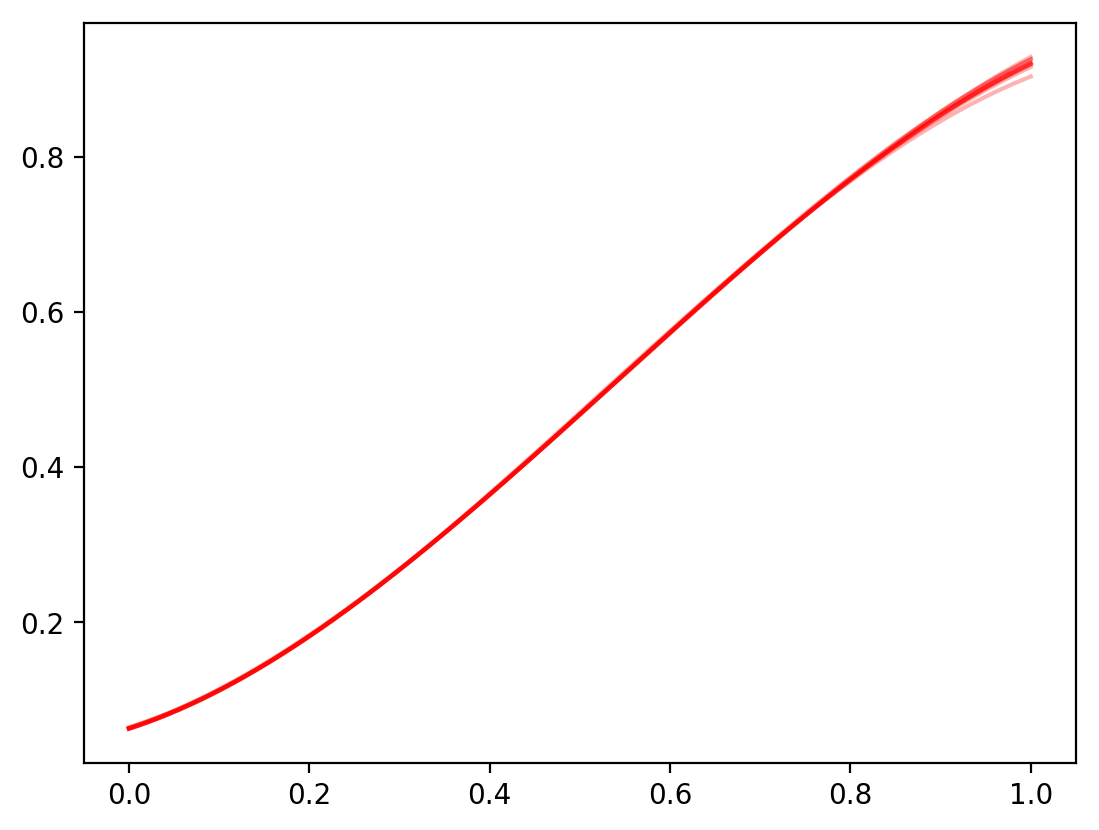

In [94]:
x = np.linspace(0,1, 1000)
for i in range(10):
    plt.plot(x, fit[i][0]*x**3+fit[i][1]*x**2+fit[i][2]*x+fit[i][3], color = 'red', alpha = 0.3)
    #plt.plot(x, d['e_in'][:1000], '.', alpha = 0.3)
    #plt.plot(d['e_in'][:300], np.sqrt(df_plot_bnn['e1_out_mean'][:300]**2+df_plot_bnn['e2_out_mean'][:300]**2), '.', color = 'blue', alpha = 0.3)

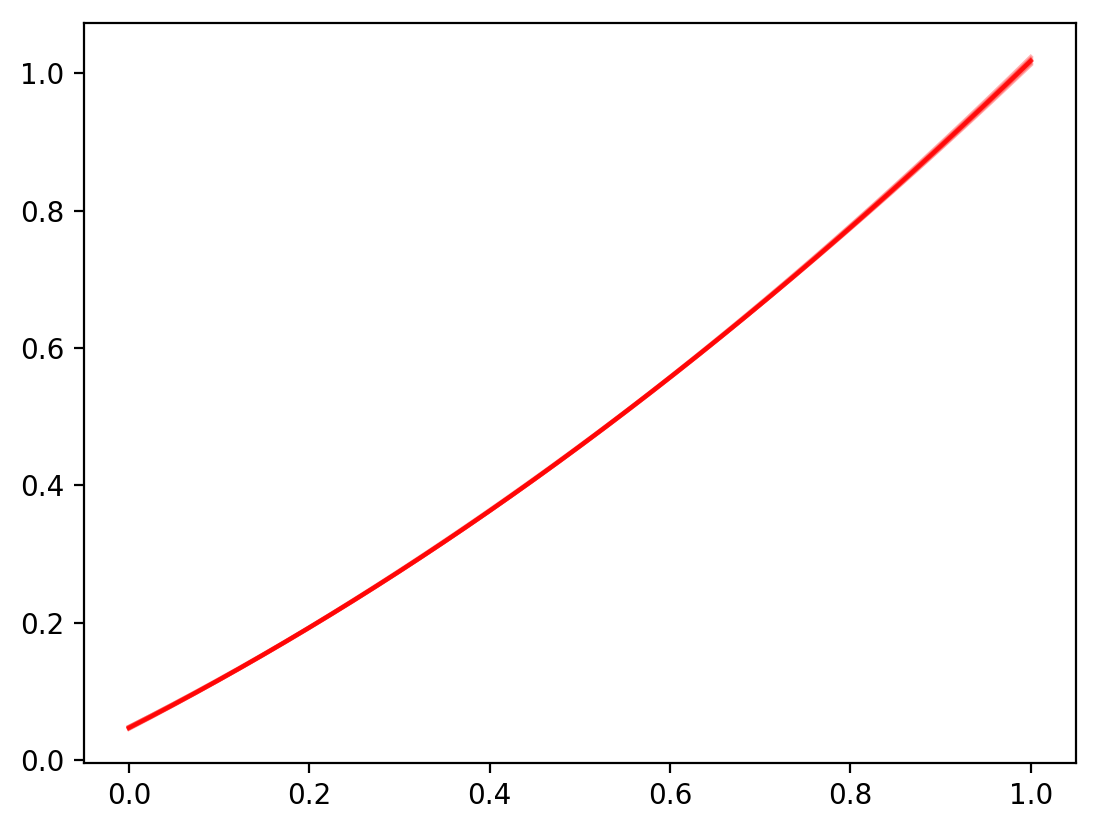

In [88]:
x = np.linspace(0,1, 1000)
for i in range(10):
    plt.plot(x, fit[i][0]*x**2+fit[i][1]*x+fit[i][2], color = 'red', alpha = 0.3)
    #plt.plot(x, d['e_in'][:1000], '.', alpha = 0.3)
    #plt.plot(d['e_in'][:300], np.sqrt(df_plot_bnn['e1_out_mean'][:300]**2+df_plot_bnn['e2_out_mean'][:300]**2), '.', color = 'blue', alpha = 0.3)

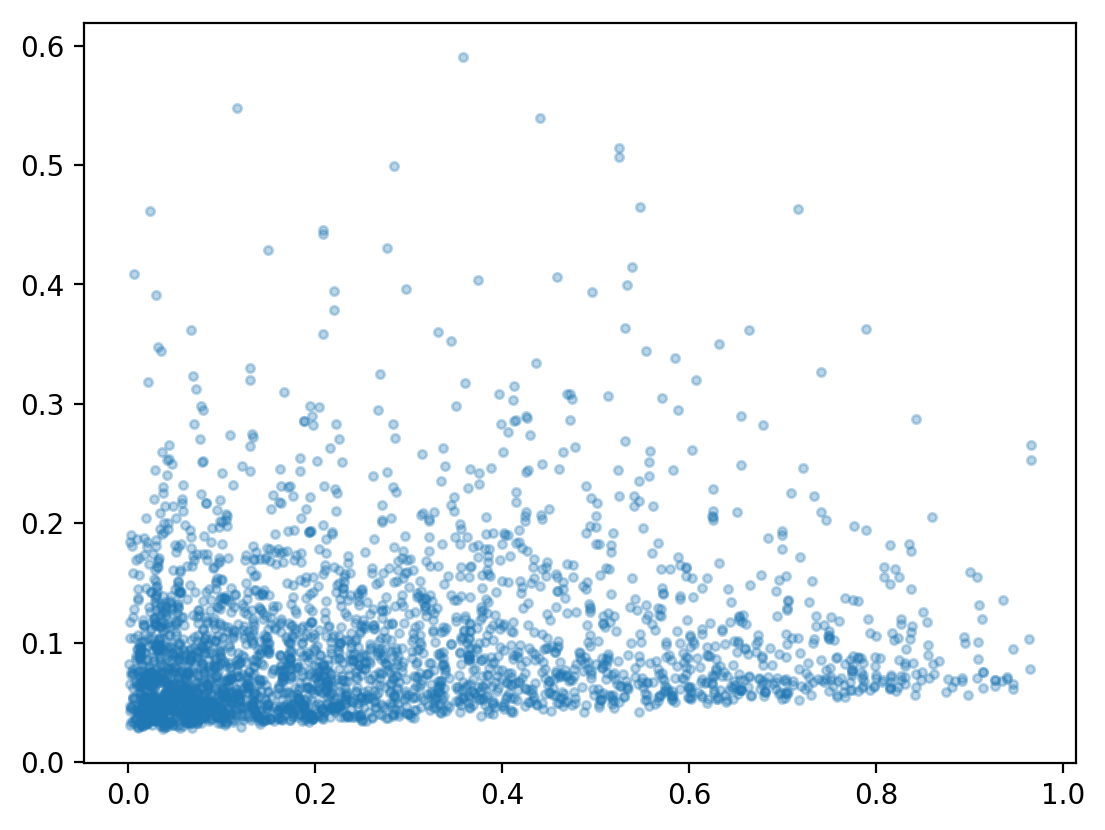

In [55]:
plt.plot(d['e_in'], np.sqrt(d['e1_std__bnn']**2+d['e2_std__bnn']**2), '.', alpha = 0.3 , label = 'epistemic uncertainty')

In [31]:
img_noiseless= np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')

In [8]:
def gaussian(mean,std,x):
    return (1/(std*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean)/(2*std**2)))

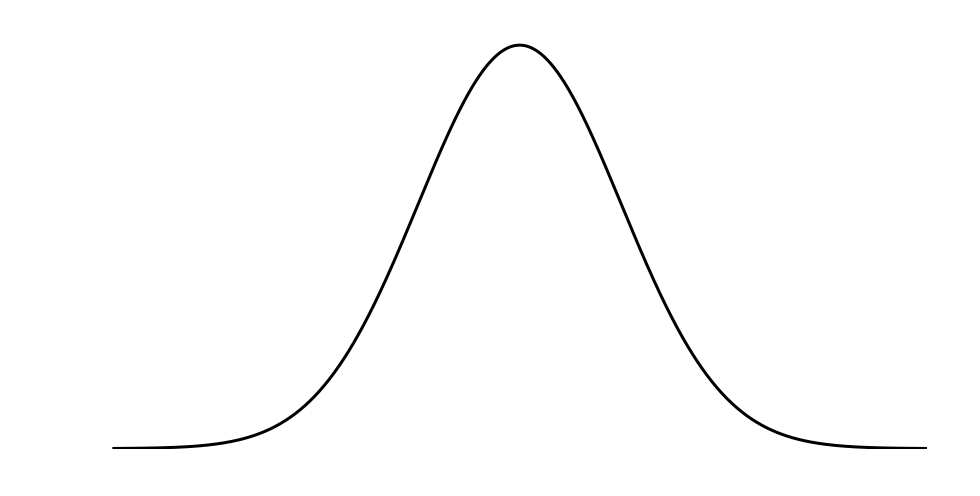

In [23]:
x = np.linspace(-4,4, 1000)
fig, ax = plt.subplots(1,1, figsize =(8,4))
ax.plot(x, gaussian(0,1,x), color = 'black')
ax.set_ylim(0,0.43)
plt.axis('off')
fig.savefig('imgs/gaussian.pdf')

W0621 16:48:33.410952 140168951428928 image.py:656] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0621 16:48:33.537330 140168951428928 image.py:656] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0621 16:48:33.644123 140168951428928 image.py:656] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


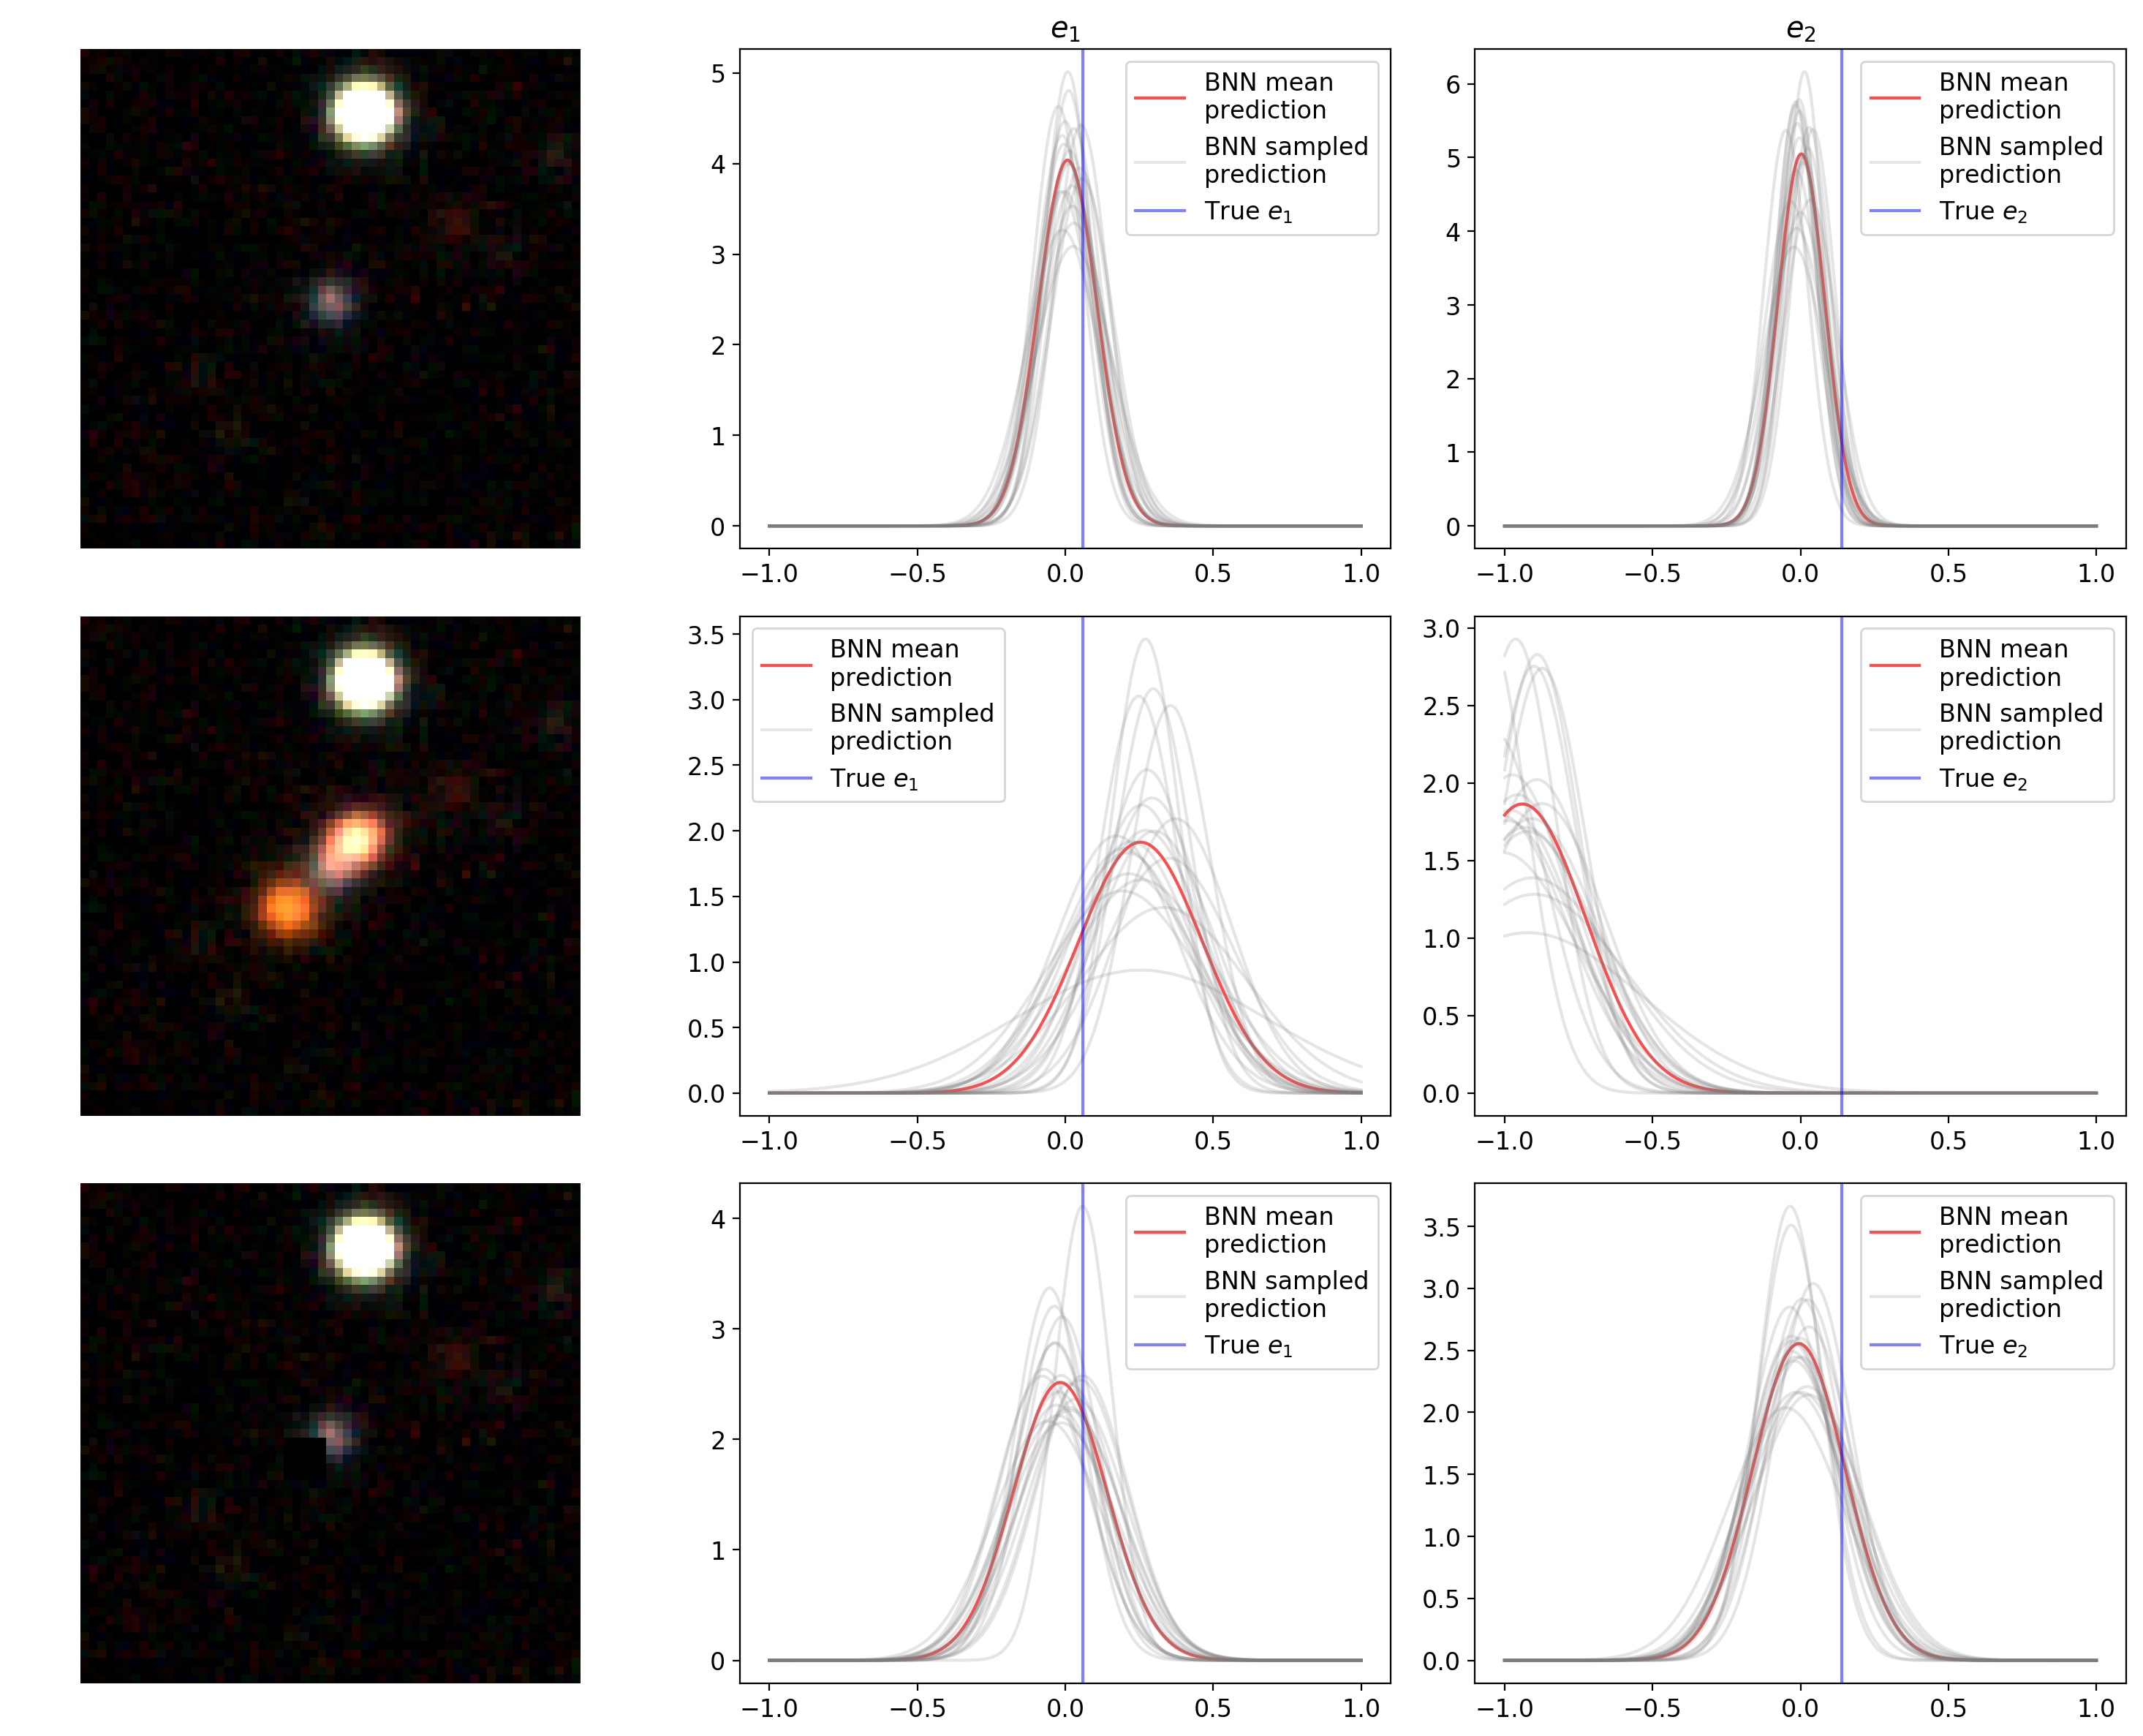

In [139]:
fig, axes = plt.subplots(3,3,figsize = (15,12))
#fig, axes = plt.subplots(1,2, figsize =(12,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)


img_nb = 1
nb_sample = 100

x = np.linspace(-1,1, 1000)
img = np.zeros((nb_sample*3,59,59,6))

img_modif = images[img_nb]+np.roll(img_noiseless[3], shift = 3, axis =(0,1))+np.roll(img_noiseless[6], shift = -5, axis =(0,1))

sub = images[img_nb].copy()#np.zeros((59,59,6))
sub[24:29,24:29,:] = np.zeros((5,5,6))
img_modif_2 =  sub

for i in range (nb_sample):
    img[i]=images[img_nb]
    img[i+nb_sample]=img_modif
    img[i+nb_sample]=img_modif_2
    
output = model_bnn([tf.cast(img, tf.float32), tf.cast(psf[0:nb_sample*3], tf.float32)])

mean = K.get_value(output.mean())
std = K.get_value(output.stddev())

e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

plot.plot_rgb(images[img_nb], bands = [3,2,1],ax= axes[0,0], band_first= False,zoom = 1,)
axes[0,1].plot(x, gaussian(np.mean(e1_out_mean[:nb_sample]), np.mean(e1_out_std[:nb_sample]),x), label = 'BNN mean\nprediction', color = 'red', alpha = 0.7)
for i in range (20):
    if i == 0:
        axes[0,1].plot(x, gaussian(e1_out_mean[i], e1_out_std[i],x), label = 'BNN sampled\nprediction', color = 'grey', alpha = 0.2)
    else:
        axes[0,1].plot(x, gaussian(e1_out_mean[i], e1_out_std[i],x), color = 'grey', alpha = 0.2)
axes[0,1].axvline(d['e1_in'][img_nb], color = 'blue', alpha = 0.5, label = 'True $e_1$')
axes[0,2].plot(x, gaussian(np.mean(e2_out_mean[:nb_sample]), np.mean(e2_out_std[:nb_sample]),x), label = 'BNN mean\nprediction', color = 'red', alpha = 0.7)
for i in range (20):
    if i == 0:
        axes[0,2].plot(x, gaussian(e2_out_mean[i], e2_out_std[i],x), label = 'BNN sampled\nprediction', color = 'grey', alpha = 0.2)
    else:
        axes[0,2].plot(x, gaussian(e2_out_mean[i], e2_out_std[i],x), color = 'grey', alpha = 0.2)
axes[0,2].axvline(d['e2_in'][img_nb], color = 'blue', alpha = 0.5, label = 'True $e_2$')
axes[0,1].legend()
axes[0,1].set_title('$e_1$')
axes[0,2].set_title('$e_2$')
axes[0,2].legend()        

#axes[1,0].imshow(images[0,:,:,2]+np.roll(img_noiseless[3,:,:,2], shift = 2, axis =(0,1)))
plot.plot_rgb(img_modif, bands = [3,2,1],ax= axes[1,0], band_first= False,zoom = 1,)
axes[1,1].plot(x, gaussian(np.mean(e1_out_mean[nb_sample:2*nb_sample]), np.mean(e1_out_std[nb_sample:2*nb_sample]),x), label = 'BNN mean\nprediction', color = 'red', alpha = 0.7)
for i in range (20):
    if i == 0:
        axes[1,1].plot(x, gaussian(e1_out_mean[i+nb_sample], e1_out_std[i+nb_sample],x), label = 'BNN sampled\nprediction', color = 'grey', alpha = 0.2)
    else:
        axes[1,1].plot(x, gaussian(e1_out_mean[i+nb_sample], e1_out_std[i+nb_sample],x), color = 'grey', alpha = 0.2)
axes[1,1].axvline(d['e1_in'][img_nb], color = 'blue', alpha = 0.5, label = 'True $e_1$')
axes[1,2].plot(x, gaussian(np.mean(e2_out_mean[nb_sample:nb_sample*2]), np.mean(e2_out_std[nb_sample:2*nb_sample]),x), label = 'BNN mean\nprediction', color = 'red', alpha = 0.7)
for i in range (20):
    if i == 0:
        axes[1,2].plot(x, gaussian(e2_out_mean[i+nb_sample], e2_out_std[i+nb_sample],x), label = 'BNN sampled\nprediction', color = 'grey', alpha = 0.2)
    else:
        axes[1,2].plot(x, gaussian(e2_out_mean[i+nb_sample], e2_out_std[i+nb_sample],x), color = 'grey', alpha = 0.2)
axes[1,2].axvline(d['e2_in'][img_nb], color = 'blue', alpha = 0.5, label = 'True $e_2$')
axes[1,1].legend()
axes[1,2].legend()   

#axes[1,0].imshow(images[0,:,:,2]+np.roll(img_noiseless[3,:,:,2], shift = 2, axis =(0,1)))
plot.plot_rgb(img_modif_2, bands = [3,2,1],ax= axes[2,0], band_first= False,zoom = 1,)
axes[2,1].plot(x, gaussian(np.mean(e1_out_mean[2*nb_sample:]), np.mean(e1_out_std[2*nb_sample:]),x), label = 'BNN mean\nprediction', color = 'red', alpha = 0.7)
for i in range (20):
    if i == 0:
        axes[2,1].plot(x, gaussian(e1_out_mean[i+2*nb_sample], e1_out_std[i+2*nb_sample],x), label = 'BNN sampled\nprediction', color = 'grey', alpha = 0.2)
    else:
        axes[2,1].plot(x, gaussian(e1_out_mean[i+2*nb_sample], e1_out_std[i+2*nb_sample],x), color = 'grey', alpha = 0.2)
axes[2,1].axvline(d['e1_in'][img_nb], color = 'blue', alpha = 0.5, label = 'True $e_1$')
axes[2,2].plot(x, gaussian(np.mean(e2_out_mean[2*nb_sample:]), np.mean(e2_out_std[2*nb_sample:]),x), label = 'BNN mean\nprediction', color = 'red', alpha = 0.7)
for i in range (20):
    if i == 0:
        axes[2,2].plot(x, gaussian(e2_out_mean[i+2*nb_sample], e2_out_std[i+2*nb_sample],x), label = 'BNN sampled\nprediction', color = 'grey', alpha = 0.2)
    else:
        axes[2,2].plot(x, gaussian(e2_out_mean[i+2*nb_sample], e2_out_std[i+2*nb_sample],x), color = 'grey', alpha = 0.2)
axes[2,2].axvline(d['e2_in'][img_nb], color = 'blue', alpha = 0.5, label = 'True $e_2$')
axes[2,1].legend()
axes[2,2].legend()

fig.tight_layout()
fig.savefig(('imgs/prediction_bnn_3_cases.pdf'))

In [143]:
np.abs(np.mean(e1_out_mean[:nb_sample])-d['e1_in'][img_nb]), np.abs(np.mean(e1_out_mean[nb_sample:2*nb_sample])-d['e1_in'][img_nb]),np.abs(np.mean(e1_out_mean[2*nb_sample:])-d['e1_in'][img_nb])

(0.05126537807017848, 0.19512601424276546, 0.07604250456869885)

In [140]:
np.std(e1_out_mean[:nb_sample]), np.std(e1_out_mean[nb_sample:2*nb_sample]),np.std(e1_out_mean[2*nb_sample:]), np.std(e1_out_std[:nb_sample]), np.std(e1_out_std[nb_sample:2*nb_sample]), np.std(e1_out_std[2*nb_sample:])

(0.024066526, 0.061118543, 0.03458405, 0.011622286, 0.05939038, 0.024547389)

# Comparison BNN, Det, LSST pipeline

In [57]:
df_no_psf = pd.read_csv('data/df_vae_dc2_no_psf_noisy_i.csv', encoding = 'utf-8')

In [58]:
df_plot_bnn_2 = pd.DataFrame()

df_plot_bnn_2['e1_out_mean']=np.zeros((3000))
df_plot_bnn_2['e2_out_mean']=np.zeros((3000))
df_plot_bnn_2['e1_out_al_std']=np.zeros((3000))
df_plot_bnn_2['e2_out_al_std']=np.zeros((3000))
df_plot_bnn_2['e1_out_ep_std']=np.zeros((3000))
df_plot_bnn_2['e2_out_ep_std']=np.zeros((3000))

for i in range (3000):
    df_plot_bnn_2['e1_out_mean'][i] = np.mean((df_plot_bnn['e1_out_mean'][i],df_plot_bnn['e1_out_mean'][i+3000],df_plot_bnn['e1_out_mean'][i+6000],
                                          df_plot_bnn['e1_out_mean'][i+9000],df_plot_bnn['e1_out_mean'][i+12000],df_plot_bnn['e1_out_mean'][i+15000],
                                          df_plot_bnn['e1_out_mean'][i+18000],df_plot_bnn['e1_out_mean'][i+21000],df_plot_bnn['e1_out_mean'][i+24000],
                                          df_plot_bnn['e1_out_mean'][i+27000]))
    #print()
    df_plot_bnn_2['e2_out_mean'][i] = np.mean((df_plot_bnn['e2_out_mean'][i],df_plot_bnn['e2_out_mean'][i+3000],df_plot_bnn['e2_out_mean'][i+6000],
                                          df_plot_bnn['e2_out_mean'][i+9000],df_plot_bnn['e2_out_mean'][i+12000],df_plot_bnn['e2_out_mean'][i+15000],
                                          df_plot_bnn['e2_out_mean'][i+18000],df_plot_bnn['e2_out_mean'][i+21000],df_plot_bnn['e2_out_mean'][i+24000],
                                          df_plot_bnn['e2_out_mean'][i+27000]))
    df_plot_bnn_2['e1_out_al_std'][i] = np.mean((df_plot_bnn['e1_out_std'][i],df_plot_bnn['e1_out_std'][i+3000],df_plot_bnn['e1_out_std'][i+6000],
                                          df_plot_bnn['e1_out_std'][i+9000],df_plot_bnn['e1_out_std'][i+12000],df_plot_bnn['e1_out_std'][i+15000],
                                          df_plot_bnn['e1_out_std'][i+18000],df_plot_bnn['e1_out_std'][i+21000],df_plot_bnn['e1_out_std'][i+24000],
                                          df_plot_bnn['e1_out_std'][i+27000]))
    df_plot_bnn_2['e2_out_al_std'][i] = np.mean((df_plot_bnn['e2_out_std'][i],df_plot_bnn['e2_out_std'][i+3000],df_plot_bnn['e2_out_std'][i+6000],
                                          df_plot_bnn['e2_out_std'][i+9000],df_plot_bnn['e2_out_std'][i+12000],df_plot_bnn['e2_out_std'][i+15000],
                                          df_plot_bnn['e2_out_std'][i+18000],df_plot_bnn['e2_out_std'][i+21000],df_plot_bnn['e2_out_std'][i+24000],
                                          df_plot_bnn['e2_out_std'][i+27000]))
    df_plot_bnn_2['e1_out_ep_std'][i] = np.std((df_plot_bnn['e1_out_mean'][i],df_plot_bnn['e1_out_mean'][i+3000],df_plot_bnn['e1_out_mean'][i+6000],
                                          df_plot_bnn['e1_out_mean'][i+9000],df_plot_bnn['e1_out_mean'][i+12000],df_plot_bnn['e1_out_mean'][i+15000],
                                          df_plot_bnn['e1_out_mean'][i+18000],df_plot_bnn['e1_out_mean'][i+21000],df_plot_bnn['e1_out_mean'][i+24000],
                                          df_plot_bnn['e1_out_mean'][i+27000]))
    df_plot_bnn_2['e2_out_ep_std'][i] = np.std((df_plot_bnn['e2_out_mean'][i],df_plot_bnn['e2_out_mean'][i+3000],df_plot_bnn['e2_out_mean'][i+6000],
                                          df_plot_bnn['e2_out_mean'][i+9000],df_plot_bnn['e2_out_mean'][i+12000],df_plot_bnn['e2_out_mean'][i+15000],
                                          df_plot_bnn['e2_out_mean'][i+18000],df_plot_bnn['e2_out_mean'][i+21000],df_plot_bnn['e2_out_mean'][i+24000],
                                          df_plot_bnn['e2_out_mean'][i+27000]))

In [64]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1_det'] = df_plot_det['e1_out_mean'][:3000]
d['e2_det'] = df_plot_det['e2_out_mean'][:3000]
d['e1_std_det'] = df_plot_det['e1_out_std'][:3000]
d['e2_std_det'] = df_plot_det['e2_out_std'][:3000]

d['e1_bnn'] = df_plot_bnn_2['e1_out_mean']
d['e2_bnn'] = df_plot_bnn_2['e2_out_mean']
d['e1_std_al_bnn'] = df_plot_bnn_2['e1_out_al_std']
d['e2_std_al_bnn'] = df_plot_bnn_2['e2_out_al_std']
d['e1_std_ep_bnn'] = df_plot_bnn_2['e1_out_ep_std']
d['e2_std_ep_bnn'] = df_plot_bnn_2['e2_out_ep_std']
d['e1_in'] = -e1[:3000]
d['e2_in'] = e2[:3000]
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([df_no_psf['e1_out_reg'][:3000],d['e1_bnn']], ignore_index = True)
df['e_2'] = pd.concat([df_no_psf['e2_out_reg'][:3000],d['e2_bnn']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(df_no_psf['e1_out_reg'][:3000]**2+df_no_psf['e2_out_reg'][:3000]**2),np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']

df['blendedness'] = pd.concat([data['blendedness'][:3000],data['blendedness'][:3000]], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'][:3000],data['snr_r'][:3000]], ignore_index = True)

df['exp'] = [1]*3000+[2]*3000

df_plot_2 = df[df['blendedness']>0]

In [65]:
df_no_psf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
Unnamed: 0         10000 non-null int64
id                 10000 non-null int64
e1                 10000 non-null float64
e2                 10000 non-null float64
shear_1            10000 non-null float64
shear_2            10000 non-null float64
redshift           10000 non-null float64
redshift_true      10000 non-null float64
blendedness        9999 non-null float64
snr_r              9998 non-null float64
convergence        10000 non-null float64
e1_hsm_regauss     9976 non-null float64
e2_hsm_regauss     9976 non-null float64
mag_r_meas         9998 non-null float64
mag_r_true         10000 non-null float64
e1_in_ksb          9951 non-null float64
e1_out_ksb         9951 non-null float64
e1_error_ksb       9951 non-null float64
e2_in_ksb          9951 non-null float64
e2_out_ksb         9951 non-null float64
e2_error_ksb       9951 non-null float64
e_in_ksb           9951 n

In [66]:
df_plot_2 = df[df['blendedness']>0]

4844
[1 2]
0 1
1 2


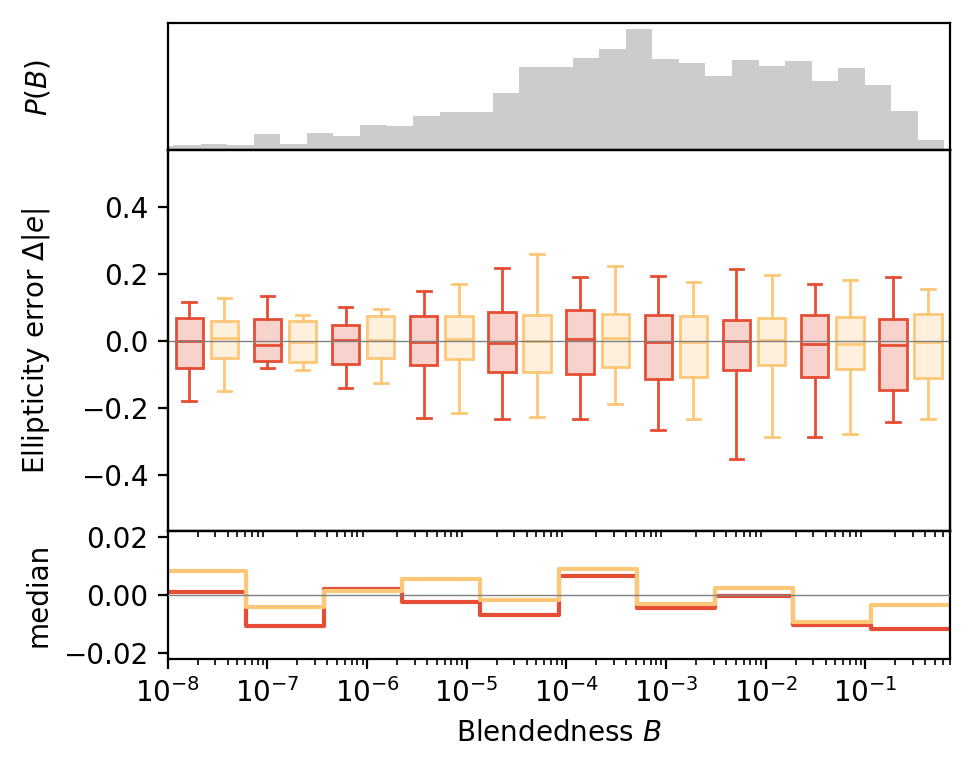

In [78]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-.57, .57),
              ylim2= (-0.022, 0.022),
              x_scale = 'log',
              legend = ['DebVAder', 'BNN parameters estimation'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15,0.35]),
              nbins = 10)

fig.savefig('imgs/e_blend_dc2_debvader_BNN.pdf')

4844
[1 2]
0 1
1 2


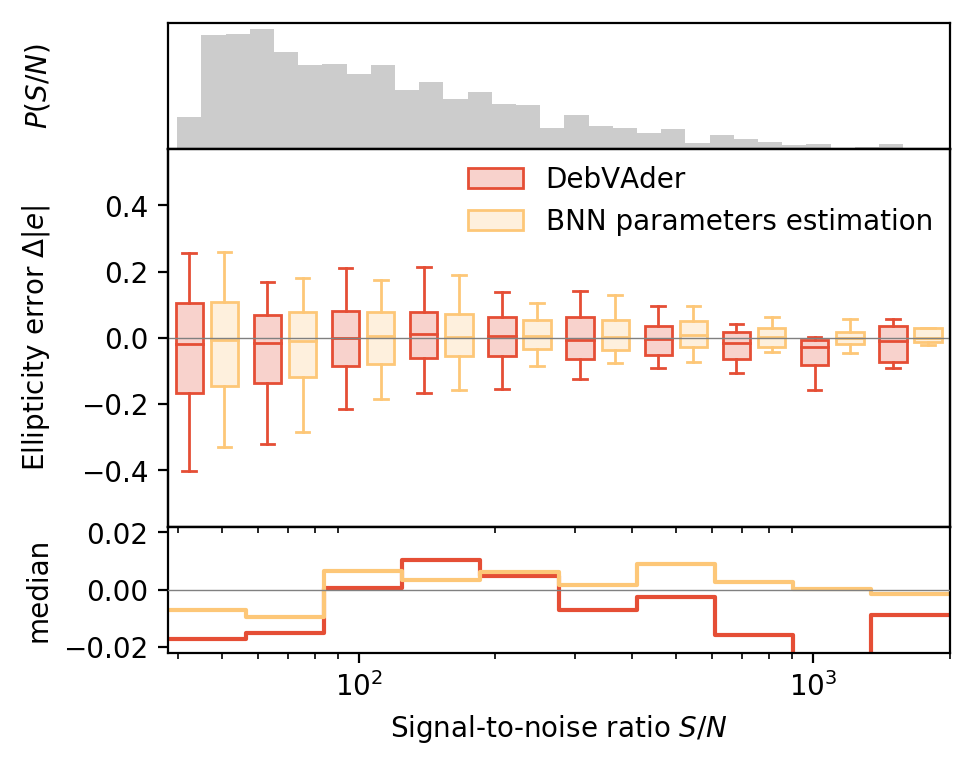

In [79]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2000),
              ylim = (-.57, .57),
              ylim2= (-0.022, 0.022),
              x_scale = 'log',
              legend = ['DebVAder', 'BNN parameters estimation'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15,0.35]),
              nbins = 10)

fig.savefig('imgs/e_snr_dc2_debvader_BNN.pdf')